# Preprocessing Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
order = pd.read_csv('/content/drive/MyDrive/Purwadhika/Modul 3/Dekoruma case/dekoruma_orders.csv')
product = pd.read_csv('/content/drive/MyDrive/Purwadhika/Modul 3/Dekoruma case/dekoruma_products.csv')
store = pd.read_csv('/content/drive/MyDrive/Purwadhika/Modul 3/Dekoruma case/dekoruma_stores.csv')

Tersedia 3 tabel yang memuat informasi tentang fakta transaksi di tabel `order`, informasi mengenai detail produk di tabel `product`, dan informasi tentang toko dan channel penjualan di tabel `store`. Preproses data dilakukan untuk memastikan validitas data di masing-masing tabel.


> **Dtype, Missing Value, Duplicate, and Invalid Value.**






### Table Product

Data product akan dieksplorasi dengan objektif sebagai berikut:

1.   Check missing value and duplicate
2.   Check Data type masing-masing kolom
3.   Check data label pada columns `category`, `product_name`, dan `is_assembly_required`.  



>Catatan: Explorasi data dilakukan untuk mengidentifikasi masalah dan menarik insight serta memastikan data siap dianalisis lebih mendalam.




In [ ]:
product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   sku_id                1500 non-null   object
 1   product_name          1500 non-null   object
 2   category              1500 non-null   object
 3   is_assembly_required  1500 non-null   bool  
dtypes: bool(1), object(3)
memory usage: 36.8+ KB


In [ ]:
product.head()

,sku_id,product_name,category,is_assembly_required
0,SKU-FURN-00001,Furnitur Kayu Olahan 407,Office Chair,True
1,SKU-FURN-00002,Furnitur Kayu Olahan 536,Wardrobe,True
2,SKU-FURN-00003,Sofa Japandi Minimalis 867,Sofa,True
3,SKU-FURN-00004,Furnitur Kayu Olahan 727,Kursi Kerja,True
4,SKU-FURN-00005,Furnitur Kayu Olahan 363,Wardrobe,True


In [ ]:
product.isna().sum()

,0
sku_id,0
product_name,0
category,0
is_assembly_required,0


In [ ]:
product.duplicated().sum()

np.int64(0)

In [ ]:
product.category.unique()

array(['Office Chair', 'Wardrobe', 'Sofa', 'Kursi Kerja', 'Lemari',
       'sofabed', 'Dekorasi', 'Dining Table', 'lmri', 'Meja Makan', 'Bed'],
      dtype=object)

Standarisasi column `category` menjadi:
1. 'Office Chair'
2. 'Wardrobe'
3. 'Sofa'
4. 'Sofabed'
5. 'Dekorasi'
6. 'Dining Table'
7. 'Bed'

In [ ]:
cat_map = {
    'Kursi Kerja':'Office Chair',
    'sofabed':'Sofabed',
    'Meja Makan': 'Dining Table',
    'lmri':'Wardrobe',
    'Lemari': 'Wardrobe'}

product.category = product.category.apply(lambda x: cat_map[x] if x in cat_map else x)
product.category.unique()

array(['Office Chair', 'Wardrobe', 'Sofa', 'Sofabed', 'Dekorasi',
       'Dining Table', 'Bed'], dtype=object)

In [ ]:
product.category.value_counts()

,count
category,
Wardrobe,348
Office Chair,330
Dining Table,234
Dekorasi,215
Sofa,214
Sofabed,81
Bed,78


In [ ]:
product.product_name.nunique()

918

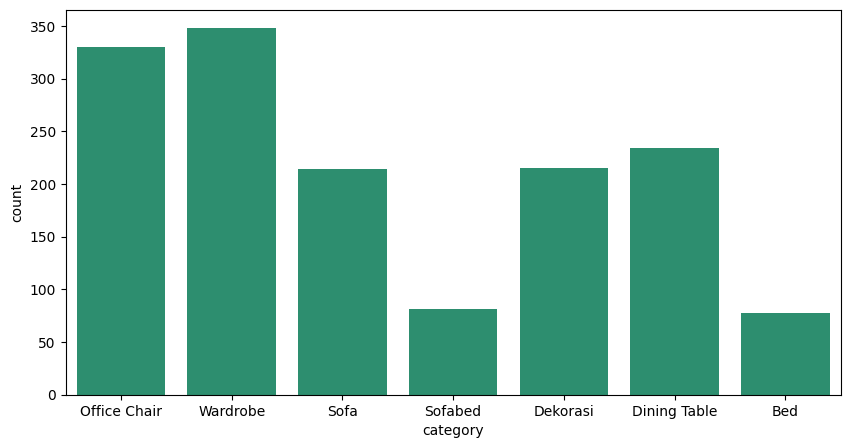

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=product, x='category', color='#1D9E75')
plt.show()

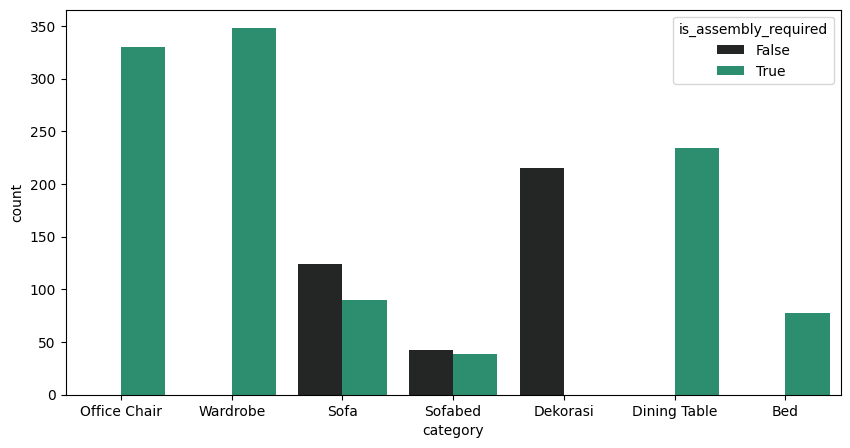

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=product, x='category', color='#1D9E75', hue='is_assembly_required')
plt.show()

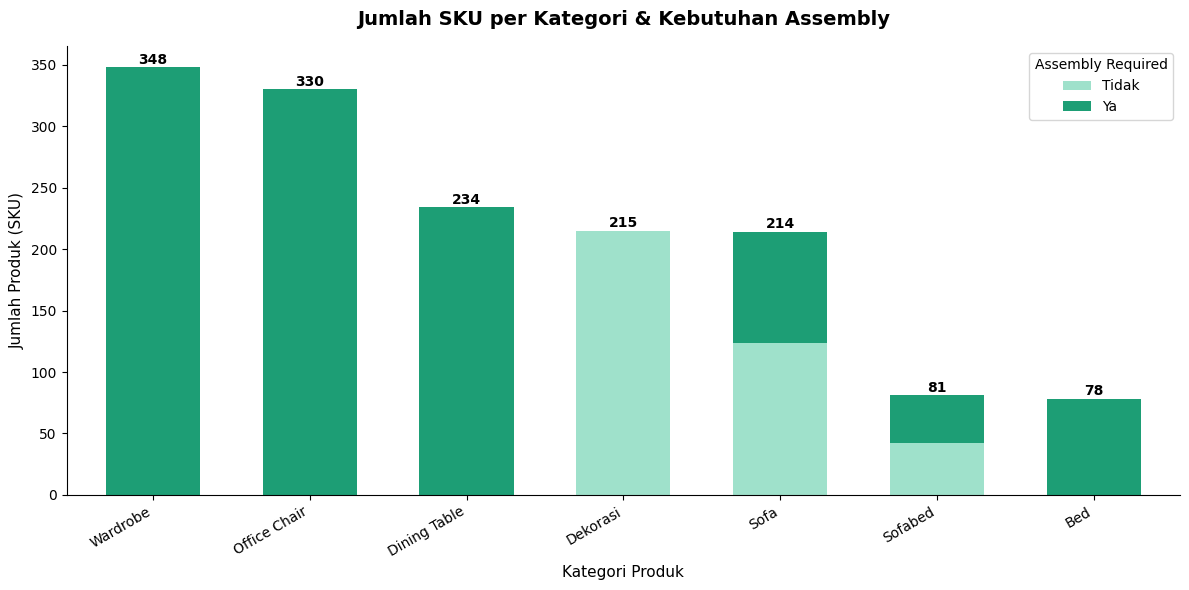

In [ ]:
# Pivot untuk stacked
pivot = (product.groupby(['category', 'is_assembly_required'])
         .size().unstack(fill_value=0))
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(12, 6))

pivot.plot(
    kind='bar',
    stacked=True,
    color={True: '#1D9E75', False: '#9FE1CB'},
    ax=ax,
    width=0.6
)

# Annotasi total di atas bar
for i, total in enumerate(pivot.sum(axis=1)):
    ax.text(i, total + 3, str(int(total)), ha='center', fontsize=10, fontweight='bold')

ax.set_title('Jumlah SKU per Kategori & Kebutuhan Assembly', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Kategori Produk', fontsize=11)
ax.set_ylabel('Jumlah Produk (SKU)', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(title='Assembly Required', labels=['Tidak', 'Ya'])

plt.tight_layout()
plt.show()

#### Hasil Exploration Data Analysis:

1.   Table Product tidak memiliki missing value dan duplicate
2.   Data type masing-masing kolom sudah sesuai
3.   Column `category` belum memiliki standar yang baku sehingga terdapat data yang harusnya dalam kategori yang sama namun diberi label berbeda. Ex.: `Kursi Kerja` dan `Office Chair`. Nilai column `category` distandarisasi terlebih dahulu dengan mengubah setiap nilai unik menjadi satu standar nilai baku.
4.   Mayoritas product yang dijual membutuhkan membutuhkan jasa instalasi. Hanya produk dekorasi dan sebagian sofa dan sofabed yang tidak membutuhkannya. **Hal ini membuat jasa installasi menjadi fitur tambahan yang penting.**



> Data pada table product sudah sepenuhnya valid. Hasil explorasi menunjukkan mayoritas product adalah product dengan kebutuhan jasa instalasi. Hal ini tentu menyebabkan implikasi bisnis tambahan sebagai add-on-service yang turut mempengaruhi keputusan beli dan user experience.



### Table Store
Data store akan dieksplorasi dengan objektif sebagai berikut:

1.   Check missing value and duplicate
2.   Check Data type masing-masing kolom
3.   Check data label pada columns `store_name` dan `channel_type`.  

In [ ]:
store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   store_id      40 non-null     object
 1   store_name    40 non-null     object
 2   channel_type  40 non-null     object
dtypes: object(3)
memory usage: 1.1+ KB


In [ ]:
store.head()

,store_id,store_name,channel_type
0,DKR-001,DEC Alam Sutera 1,Physical Store
1,DKR-002,DEC Bintaro 2,Physical Store
2,DKR-003,DEC Kemang 3,Physical Store
3,DKR-004,DEC Kelapa Gading 4,Physical Store
4,DKR-005,DEC Medan 5,Physical Store


In [ ]:
store.groupby('channel_type').size()

,0
channel_type,
Mobile App,1
Physical Store,38
Web,1


In [ ]:
store.isna().sum()

,0
store_id,0
store_name,0
channel_type,0


In [ ]:
store.duplicated().sum()

np.int64(0)

In [ ]:
store.store_name.nunique()

40

In [ ]:
store.store_name.unique()

array(['DEC Alam Sutera 1', 'DEC Bintaro 2', 'DEC Kemang 3',
       'DEC Kelapa Gading 4', 'DEC Medan 5', 'DEC Kemang 6',
       'DEC Surabaya 7', 'DEC Bandung 8', 'DEC Kelapa Gading 9',
       'DEC Kemang 10', 'DEC Kelapa Gading 11', 'DEC Bintaro 12',
       'DEC Surabaya 13', 'DEC Kelapa Gading 14', 'DEC Bekasi 15',
       'DEC Bekasi 16', 'DEC Medan 17', 'DEC Alam Sutera 18',
       'DEC Alam Sutera 19', 'DEC Surabaya 20', 'DEC Bekasi 21',
       'DEC Alam Sutera 22', 'DEC Kelapa Gading 23', 'DEC Alam Sutera 24',
       'DEC Bekasi 25', 'DEC Bandung 26', 'DEC Alam Sutera 27',
       'DEC Surabaya 28', 'DEC Kelapa Gading 29', 'DEC Kemang 30',
       'DEC Bintaro 31', 'DEC Medan 32', 'DEC Alam Sutera 33',
       'DEC Bintaro 34', 'DEC Surabaya 35', 'DEC Alam Sutera 36',
       'DEC Kelapa Gading 37', 'DEC Bintaro 38', 'Dekoruma Mobile App',
       'Dekoruma Website'], dtype=object)

In [ ]:
store.store_id.nunique()

40

#### Hasil Exploration Data Analysis:

1.   Table Store tidak memiliki missing value dan duplicate
2.   Data type masing-masing kolom sudah sesuai

Data disimpulkan sudah valid dan siap digunakan.

### Table Order

Data order akan dieksplorasi dengan objektif sebagai berikut:
1. Check missing value and duplicate
2. Check Data type masing-masing kolom
3. Check data distribution
4. Add new column untuk variabel tambahan

In [ ]:
order.isna().sum()

,0
order_id,0
store_id,0
sku_id,0
order_date,0
delivery_date,0
installer_id,109725
installation_date,109725
installation_status,0
assembly_fee,0


In [ ]:
order.duplicated().sum()

np.int64(0)

In [ ]:
order.groupby('installation_status').size()

,0
installation_status,
Failed - Damaged Panel,15279
Failed - Missing Parts,22639
No Assembly Required,76030
No Assembly Service,33695
Success,152357


In [ ]:
no_assembly = (order['installation_status'] == 'No Assembly Service').sum() + (order['installation_status'] == 'No Assembly Required').sum()
print(f'Jumlah baris order yang tidak menggunakan assembly services dan bukan barang yang membutuhkan assembly: {no_assembly}')

Jumlah baris order yang tidak menggunakan assembly services dan bukan barang yang membutuhkan assembly: 109725


In [ ]:
print(len(order.order_id)-no_assembly)

190275


Missing Value pada table order di kolom `installer_id` dan `installation_date` disebabkan oleh order barang yang tidak membutuhkan jasa instalasi dan barang yang tidak mengajukan layanan instalasi. Untuk mempertahankan analisis sesuai business context, data order yang digunakan hanya data yang membutuhkan assembly service.


> Missing value pada columns `installer_id` dan `installation_date` bukan data invalid, tetapi merupakan jumlah transaksi yang tidak membutuhkan jasa instalasi atau tidak meminta jasa instalasi.

In [ ]:
order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   order_id             300000 non-null  object
 1   store_id             300000 non-null  object
 2   sku_id               300000 non-null  object
 3   order_date           300000 non-null  object
 4   delivery_date        300000 non-null  object
 5   installer_id         190275 non-null  object
 6   installation_date    190275 non-null  object
 7   installation_status  300000 non-null  object
 8   assembly_fee         300000 non-null  int64 
dtypes: int64(1), object(8)
memory usage: 20.6+ MB


In [ ]:
order.head()

,order_id,store_id,sku_id,order_date,delivery_date,installer_id,installation_date,installation_status,assembly_fee
0,ORD-DKR00000001,DKR-029,SKU-FURN-00208,2023-08-10 17:00:00,2023-08-14 17:00:00,TUKANG-0882,2023-08-18 17:00:00,Success,120000
1,ORD-DKR00000002,DKR-012,SKU-FURN-01157,2023-01-30 10:00:00,2023-02-02 10:00:00,TUKANG-0560,2023-02-02 10:00:00,Success,110000
2,ORD-DKR00000003,DKR-032,SKU-FURN-00904,2023-07-13 20:00:00,2023-07-19 20:00:00,TUKANG-0631,2023-07-24 20:00:00,Success,230000
3,ORD-DKR00000004,DKR-005,SKU-FURN-00341,2023-09-27 19:00:00,2023-10-02 19:00:00,TUKANG-0484,2023-10-04 19:00:00,Success,100000
4,ORD-DKR00000005,DKR-019,SKU-FURN-01500,2023-12-15 12:00:00,2023-12-22 12:00:00,NaN,NaN,No Assembly Service,0


Data type semua kolom yang memuat tanggal atau `date` masih berupa object. Sehingga perlu ditransformasi menjadi datetime.

In [ ]:
order.order_date = pd.to_datetime(order.order_date)
order.delivery_date = pd.to_datetime(order.delivery_date)
order.installation_date = pd.to_datetime(order.installation_date)
order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             300000 non-null  object        
 1   store_id             300000 non-null  object        
 2   sku_id               300000 non-null  object        
 3   order_date           300000 non-null  datetime64[ns]
 4   delivery_date        300000 non-null  datetime64[ns]
 5   installer_id         190275 non-null  object        
 6   installation_date    190275 non-null  datetime64[ns]
 7   installation_status  300000 non-null  object        
 8   assembly_fee         300000 non-null  int64         
dtypes: datetime64[ns](3), int64(1), object(5)
memory usage: 20.6+ MB


**Cek data invalid berdasarkan tanggal pengiriman barang dan tanggal instalasi barang.** Case ini dapat terjadi karena human error pada saat input tanggal atau kesalahan lainnya.

In [ ]:
is_anomaly = order[order['delivery_date'] > order['installation_date']]
is_anomaly

,order_id,store_id,sku_id,order_date,delivery_date,installer_id,installation_date,installation_status,assembly_fee
180,ORD-DKR00000181,DKR-032,SKU-FURN-01054,2023-07-28 11:00:00,2023-07-31 11:00:00,TUKANG-0844,2023-07-28 11:00:00,Success,90000
247,ORD-DKR00000248,DKR-040,SKU-FURN-00870,2023-10-20 19:00:00,2023-10-25 19:00:00,TUKANG-0652,2023-10-24 19:00:00,Success,50000
267,ORD-DKR00000268,DKR-015,SKU-FURN-00679,2023-04-10 13:00:00,2023-04-17 13:00:00,TUKANG-0508,2023-04-15 13:00:00,Success,70000
287,ORD-DKR00000288,DKR-021,SKU-FURN-00934,2023-08-07 19:00:00,2023-08-14 19:00:00,TUKANG-0810,2023-08-12 19:00:00,Success,250000
369,ORD-DKR00000370,DKR-026,SKU-FURN-00128,2023-08-30 14:00:00,2023-09-06 14:00:00,TUKANG-0340,2023-09-04 14:00:00,Success,90000
...,...,...,...,...,...,...,...,...,...
299746,ORD-DKR00299747,DKR-036,SKU-FURN-00679,2023-08-20 09:00:00,2023-08-25 09:00:00,TUKANG-0721,2023-08-22 09:00:00,Success,230000
299765,ORD-DKR00299766,DKR-031,SKU-FURN-00438,2023-12-02 20:00:00,2023-12-04 20:00:00,TUKANG-0817,2023-12-01 20:00:00,Success,250000
299851,ORD-DKR00299852,DKR-026,SKU-FURN-01018,2023-12-01 15:00:00,2023-12-06 15:00:00,TUKANG-0133,2023-12-04 15:00:00,Success,180000
299853,ORD-DKR00299854,DKR-018,SKU-FURN-00470,2023-07-21 14:00:00,2023-07-24 14:00:00,TUKANG-0483,2023-07-23 14:00:00,Success,220000


In [ ]:
is_anomaly.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4570 entries, 180 to 299912
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   order_id             4570 non-null   object        
 1   store_id             4570 non-null   object        
 2   sku_id               4570 non-null   object        
 3   order_date           4570 non-null   datetime64[ns]
 4   delivery_date        4570 non-null   datetime64[ns]
 5   installer_id         4570 non-null   object        
 6   installation_date    4570 non-null   datetime64[ns]
 7   installation_status  4570 non-null   object        
 8   assembly_fee         4570 non-null   int64         
dtypes: datetime64[ns](3), int64(1), object(5)
memory usage: 357.0+ KB


In [ ]:
is_anomaly.groupby('installation_status')['installer_id'].count()

,installer_id
installation_status,
Success,4570


In [ ]:
print(f'Data error sebanyak {len(is_anomaly)} baris')

Data error sebanyak 4570 baris


Data invalid berdasarkan tanggal pengiriman barang dan tanggal instalasi barang. Data invalid menunjukkan tanggal instalasi terjadi sebelum tanggal pengiriman barang sehingga dianggap anomali.

*   Diketahui terdapat 4570 baris data invalid.

>Maka dari itu diperlukan analisis lebih lanjut terhadap data yang memuat nilai anomali tersebut. Sehingga dapat diketahui pola permasalahan yang terjadi.

#### **Exploration Data (Anomaly) Analysis**

Analisis akan dilakukan dengan:
1. Analisis pola input date untuk melihat apakah ada kemungkinan kesalahan installer atau ekspedisi dalam memasukkan tanggal instalasi dan pengiriman. Hipotesis dari permasalahan ini adalah off-by-one-month dengan asumsi kemungkinan installer atau ekspedisi salah membuat input date baik pada `installation_date` atau `delivery_date`.
2. Melihat sebaran kesalahan berdasar `store_id` dan `installer_id` untuk deteksi kesalahan input tertentu (indikasi human error).
3. Melihat data invalid di tiap bulan untuk mendeteksi apakah hal ini merupakan kesalahan dari sistem atau terdapat human error. Jika, error merupakan kesalahan sistem, maka setiap bulan akan dijumpai error serupa yang tersebar merata. Namun, jika human error, maka anomali seharusnya terpusat pada rentang waktu tertentu misalnya ketika crowded harbolnas atau event promo lainnya.

In [ ]:
# Coba koreksi: tambah 1 bulan ke installation_date
is_anomaly['installation_date_corrected'] = is_anomaly['installation_date'] + pd.DateOffset(months=1)

# Cek apakah setelah koreksi, installation_date >= delivery_date (jadi valid)
is_anomaly['is_off_by_one_month'] = (
    is_anomaly['installation_date_corrected'] >= is_anomaly['delivery_date']
)

In [ ]:
# Ringkasan
total_anomaly = len(is_anomaly)
off_by_one = is_anomaly['is_off_by_one_month'].sum()
other = total_anomaly - off_by_one

print(f"Total anomali          : {total_anomaly:,}")
print(f"Off-by-one-month       : {off_by_one:,} ({off_by_one/total_anomaly*100:.1f}%)")
print(f"Anomali pola lain      : {other:,} ({other/total_anomaly*100:.1f}%)")

Total anomali          : 4,570
Off-by-one-month       : 4,570 (100.0%)
Anomali pola lain      : 0 (0.0%)


In [ ]:
# Investigasi 1: apakah anomali terkonsentrasi di store tertentu?
is_anomaly.groupby('store_id')['is_off_by_one_month'].agg(
    total='count',
    off_by_one='sum'
).assign(pct=lambda x: (x['off_by_one']/x['total']*100).round(1)
).sort_values('total', ascending=False)

,total,off_by_one,pct
store_id,,,
DKR-001,146,146,100.0
DKR-021,138,138,100.0
DKR-014,132,132,100.0
DKR-008,132,132,100.0
DKR-033,126,126,100.0
DKR-026,125,125,100.0
DKR-038,125,125,100.0
DKR-039,125,125,100.0
DKR-030,122,122,100.0


In [ ]:
store_anomaly = is_anomaly.groupby('store_id')['is_off_by_one_month'].agg(
    total='count',
    off_by_one='sum'
).assign(pct=lambda x: (x['off_by_one']/x['total']*100).round(1)
).sort_values('total', ascending=False)
store_anomaly.count()

,0
total,40
off_by_one,40
pct,40


In [ ]:
# Investigasi 2: apakah anomali terkonsentrasi di installer tertentu?
is_anomaly.groupby('installer_id')['is_off_by_one_month'].agg(
    total='count',
    off_by_one='sum'
).assign(pct=lambda x: (x['off_by_one']/x['total']*100).round(1)
).sort_values('total', ascending=False)

,total,off_by_one,pct
installer_id,,,
TUKANG-0951,11,11,100.0
TUKANG-0264,11,11,100.0
TUKANG-0248,11,11,100.0
TUKANG-0221,11,11,100.0
TUKANG-0561,11,11,100.0
...,...,...,...
TUKANG-0223,1,1,100.0
TUKANG-0991,1,1,100.0
TUKANG-0199,1,1,100.0


In [ ]:
anomaly_installer = is_anomaly.groupby('installer_id')['is_off_by_one_month'].agg(
    total='count',
    off_by_one='sum'
).assign(pct=lambda x: (x['off_by_one']/x['total']*100).round(1)
).sort_values('total', ascending=False)


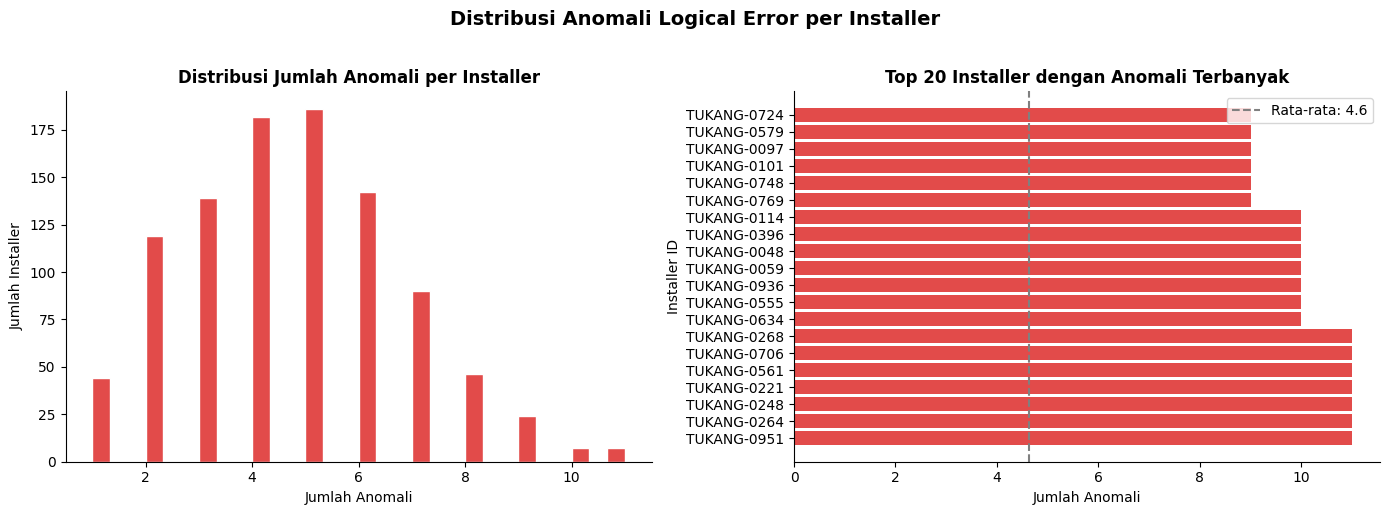

=== Statistik Distribusi Anomali per Installer ===
count    986.00
mean       4.63
std        2.04
min        1.00
25%        3.00
50%        5.00
75%        6.00
max       11.00
Name: total, dtype: float64

Installer dengan anomali > rata-rata: 502
Installer dengan hanya 1 anomali   : 44


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Distribusi total anomali per installer (histogram)
# Melihat apakah ada installer yang jauh lebih banyak anomalinya
axes[0].hist(anomaly_installer['total'], bins=30,
             color='#E24B4A', edgecolor='white')
axes[0].set_title('Distribusi Jumlah Anomali per Installer',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jumlah Anomali')
axes[0].set_ylabel('Jumlah Installer')
axes[0].spines[['top', 'right']].set_visible(False)

# Chart 2: Top 20 installer dengan anomali terbanyak
top_installer = anomaly_installer.head(20).reset_index()
axes[1].barh(top_installer['installer_id'], top_installer['total'],
             color='#E24B4A')
axes[1].axvline(anomaly_installer['total'].mean(),
                color='gray', linestyle='--', linewidth=1.5,
                label=f"Rata-rata: {anomaly_installer['total'].mean():.1f}")
axes[1].set_title('Top 20 Installer dengan Anomali Terbanyak',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jumlah Anomali')
axes[1].set_ylabel('Installer ID')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Distribusi Anomali Logical Error per Installer',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Ringkasan statistik
print("=== Statistik Distribusi Anomali per Installer ===")
print(anomaly_installer['total'].describe().round(2))
print(f"\nInstaller dengan anomali > rata-rata: {(anomaly_installer['total'] > anomaly_installer['total'].mean()).sum()}")
print(f"Installer dengan hanya 1 anomali   : {(anomaly_installer['total'] == 1).sum()}")

Hasil pengecekan menunjukkan 100% data anomali adalah mengindikasikan kasus off-by-one-month. Tingkat konsistensi yang sempurna ini mengindikasikan
bahwa anomali kemungkinan besar bukan human error acak, melainkan
systematic bug baik di level aplikasi maupun user — misalnya kesalahan parsing format tanggal yang menyebabkan bulan selalu ter-input satu bulan lebih awal atau tidak ada konfirmasi atau layer validasi untuk memastikan data sudah benar.

Temuan ini memperkuat rekomendasi untuk menutup bug di sisi sistem input, bukan sekadar membersihkan data secara manual.

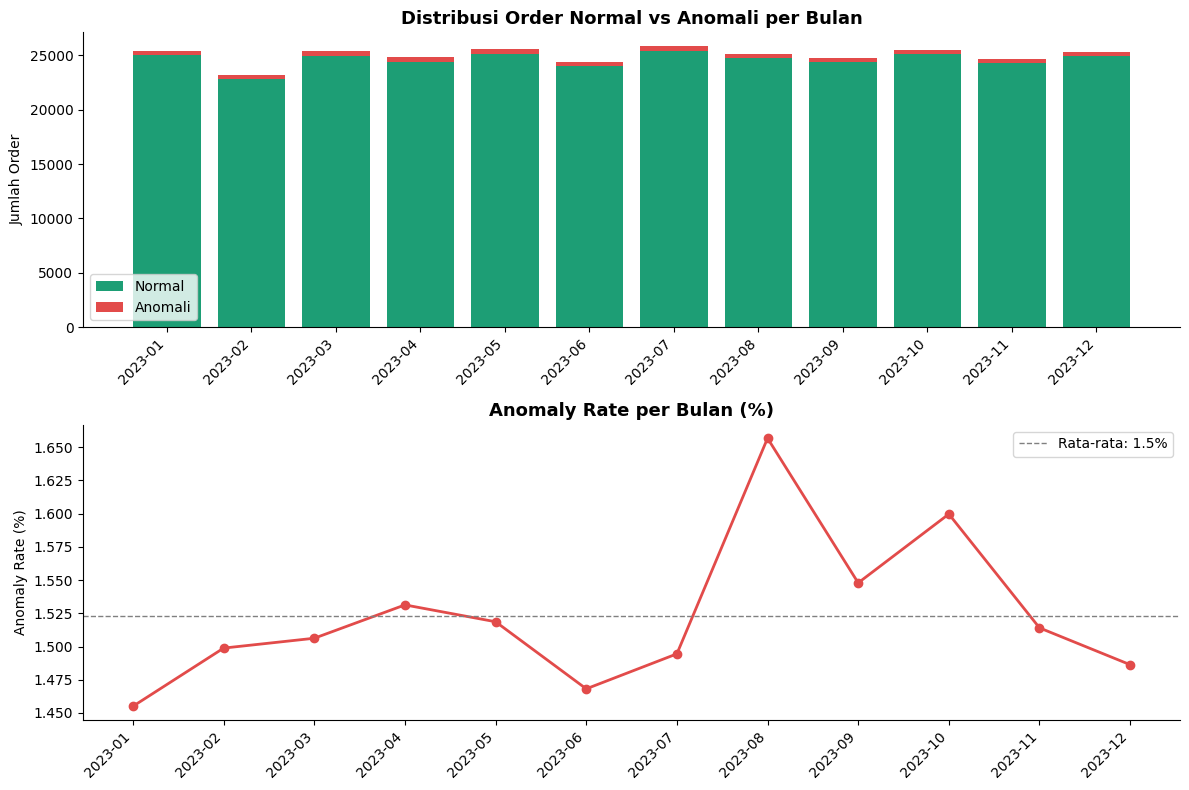

In [ ]:
# Hitung distribusi anomali vs normal per bulan
is_anomaly['month'] = is_anomaly['order_date'].dt.to_period('M')
order_clean = order[~order['order_id'].isin(is_anomaly['order_id'])].copy()
order_clean['month'] = order_clean['order_date'].dt.to_period('M')

anomaly_by_month = is_anomaly.groupby('month').size().reset_index(name='anomaly_count')
clean_by_month = order_clean.groupby('month').size().reset_index(name='clean_count')

monthly = anomaly_by_month.merge(clean_by_month, on='month', how='outer').fillna(0)
monthly['anomaly_rate'] = monthly['anomaly_count'] / (monthly['anomaly_count'] + monthly['clean_count']) * 100
monthly['month'] = monthly['month'].astype(str)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Chart 1: count anomali vs normal per bulan
axes[0].bar(monthly['month'], monthly['clean_count'], label='Normal', color='#1D9E75')
axes[0].bar(monthly['month'], monthly['anomaly_count'], bottom=monthly['clean_count'], label='Anomali', color='#E24B4A')
axes[0].set_title('Distribusi Order Normal vs Anomali per Bulan', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Order')
axes[0].set_xticklabels(monthly['month'], rotation=45, ha='right')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

# Chart 2: anomaly rate per bulan
axes[1].plot(monthly['month'], monthly['anomaly_rate'], marker='o', color='#E24B4A', linewidth=2)
axes[1].axhline(y=monthly['anomaly_rate'].mean(), color='gray', linestyle='--', linewidth=1, label=f"Rata-rata: {monthly['anomaly_rate'].mean():.1f}%")
axes[1].set_title('Anomaly Rate per Bulan (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Anomaly Rate (%)')
axes[1].set_xticklabels(monthly['month'], rotation=45, ha='right')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Anomali tersebar merata sepanjang tahun dengan rata-rata error rate 1,5% per bulan. Pola ini konsisten dengan systematic bug, bukan human error individual.

>**Rekomendasi: implementasi validasi otomatis di sistem input yang mencegah installation_date ter-submit sebelum delivery_date confirmed.**

#### **Assembly_fee**
Pemeriksaan Outlier pada kolom `assembly_fee` untuk melihat berapa banyak nilai galat yang ada pada kolom tersebut. Nilai galat ditentukan dengan Inter Quartile Range.



In [ ]:
Q1 = order['assembly_fee'].quantile(0.25)
Q3 = order['assembly_fee'].quantile(0.75)
IQR = Q3 - Q1
outlier = order[(order['assembly_fee'] < Q1 - 1.5*IQR) | (order['assembly_fee'] > Q3 + 1.5*IQR)]
print(f"Outlier assembly_fee: {len(outlier):,} baris")

Outlier assembly_fee: 933 baris


In [ ]:
outlier.assembly_fee

,assembly_fee
1355,99900000
2220,99900000
2251,99900000
2387,99900000
2550,99900000
...,...
299141,99900000
299172,99900000
299181,99900000
299337,99900000


In [ ]:
outlier.groupby('installation_status')['assembly_fee'].mean()

,assembly_fee
installation_status,
Failed - Damaged Panel,99900000.0
Failed - Missing Parts,99900000.0
Success,99900000.0


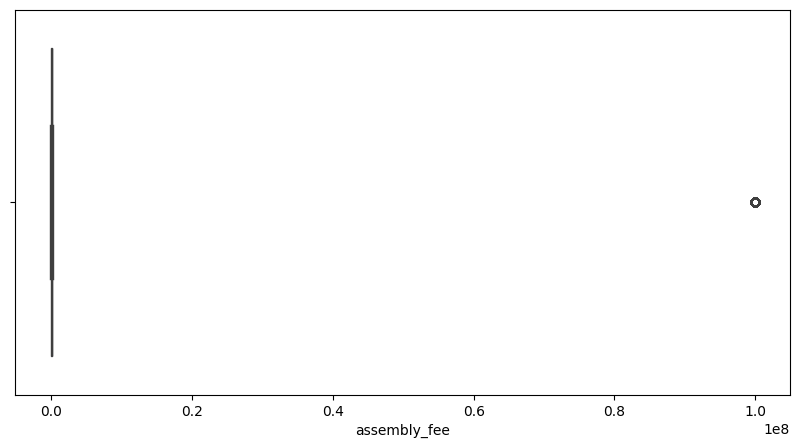

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x =order['assembly_fee'])
plt.show()
#

In [ ]:
print(order['assembly_fee'].describe())
print(f"\nNilai negatif  : {(order['assembly_fee'] < 0).sum():,} baris")
print(f"Nilai nol      : {(order['assembly_fee'] == 0).sum():,} baris")
print(f"Nilai unik     : {order['assembly_fee'].nunique()}")
print(f"\nNilai unik assembly_fee:")
print(sorted(order['assembly_fee'].unique()))

count    3.000000e+05
mean     4.044456e+05
std      5.557956e+06
min     -1.500000e+05
25%      0.000000e+00
50%      9.000000e+04
75%      1.700000e+05
max      9.990000e+07
Name: assembly_fee, dtype: float64

Nilai negatif  : 960 baris
Nilai nol      : 109,725 baris
Nilai unik     : 24

Nilai unik assembly_fee:
[np.int64(-150000), np.int64(0), np.int64(50000), np.int64(60000), np.int64(70000), np.int64(80000), np.int64(90000), np.int64(100000), np.int64(110000), np.int64(120000), np.int64(130000), np.int64(140000), np.int64(150000), np.int64(160000), np.int64(170000), np.int64(180000), np.int64(190000), np.int64(200000), np.int64(210000), np.int64(220000), np.int64(230000), np.int64(240000), np.int64(250000), np.int64(99900000)]


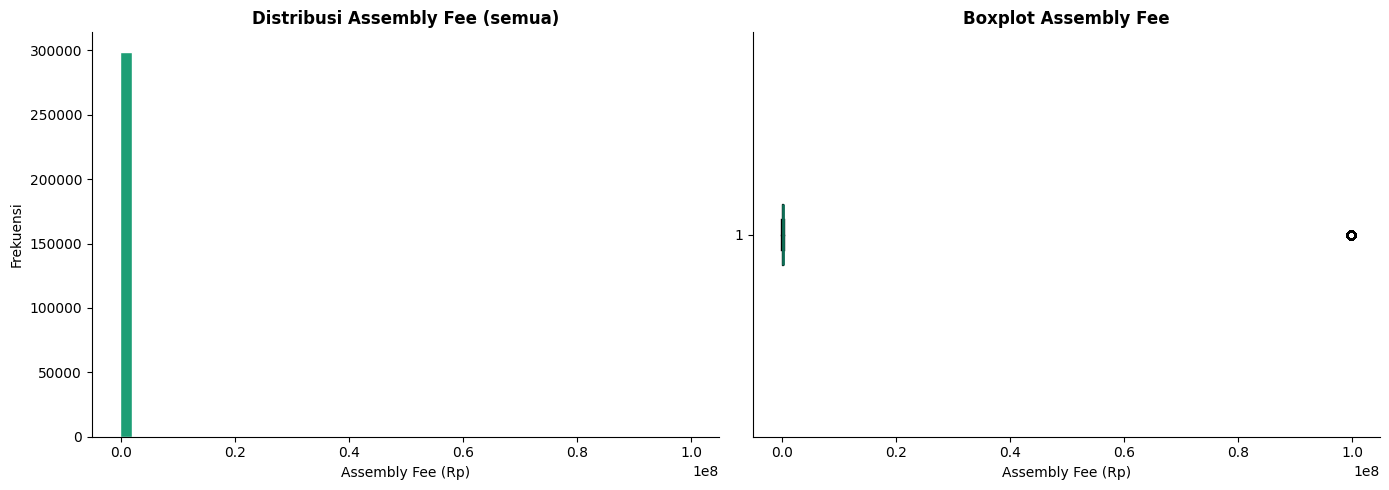

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram semua nilai
axes[0].hist(order['assembly_fee'], bins=50, color='#1D9E75', edgecolor='white')
axes[0].set_title('Distribusi Assembly Fee (semua)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Assembly Fee (Rp)')
axes[0].set_ylabel('Frekuensi')
axes[0].spines[['top', 'right']].set_visible(False)

# Boxplot
axes[1].boxplot(order['assembly_fee'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='#9FE1CB'),
                medianprops=dict(color='#0F6E56', linewidth=2))
axes[1].set_title('Boxplot Assembly Fee', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Assembly Fee (Rp)')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
Q1 = order['assembly_fee'].quantile(0.25)
Q3 = order['assembly_fee'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier = order[(order['assembly_fee'] < lower) | (order['assembly_fee'] > upper)]

print(f"Q1             : Rp {Q1:,.0f}")
print(f"Q3             : Rp {Q3:,.0f}")
print(f"IQR            : Rp {IQR:,.0f}")
print(f"Lower bound    : Rp {lower:,.0f}")
print(f"Upper bound    : Rp {upper:,.0f}")
print(f"\nTotal outlier  : {len(outlier):,} baris ({len(outlier)/len(order)*100:.1f}%)")
print(f"\nDistribusi nilai outlier:")
print(outlier['assembly_fee'].value_counts().sort_index())

Q1             : Rp 0
Q3             : Rp 170,000
IQR            : Rp 170,000
Lower bound    : Rp -255,000
Upper bound    : Rp 425,000

Total outlier  : 933 baris (0.3%)

Distribusi nilai outlier:
assembly_fee
99900000    933
Name: count, dtype: int64


In [ ]:
# Cek nilai outlier
outlier_with_cat = outlier.merge(product[['sku_id', 'category']], on='sku_id', how='left')

outlier_with_cat.groupby('category')['assembly_fee'].agg(
    jumlah='count',
    min='min',
    max='max',
    mean='mean'
).round(0).sort_values('jumlah', ascending=False)

,jumlah,min,max,mean
category,,,,
Wardrobe,290,99900000,99900000,99900000.0
Office Chair,285,99900000,99900000,99900000.0
Dining Table,179,99900000,99900000,99900000.0
Sofa,85,99900000,99900000,99900000.0
Bed,61,99900000,99900000,99900000.0
Sofabed,33,99900000,99900000,99900000.0


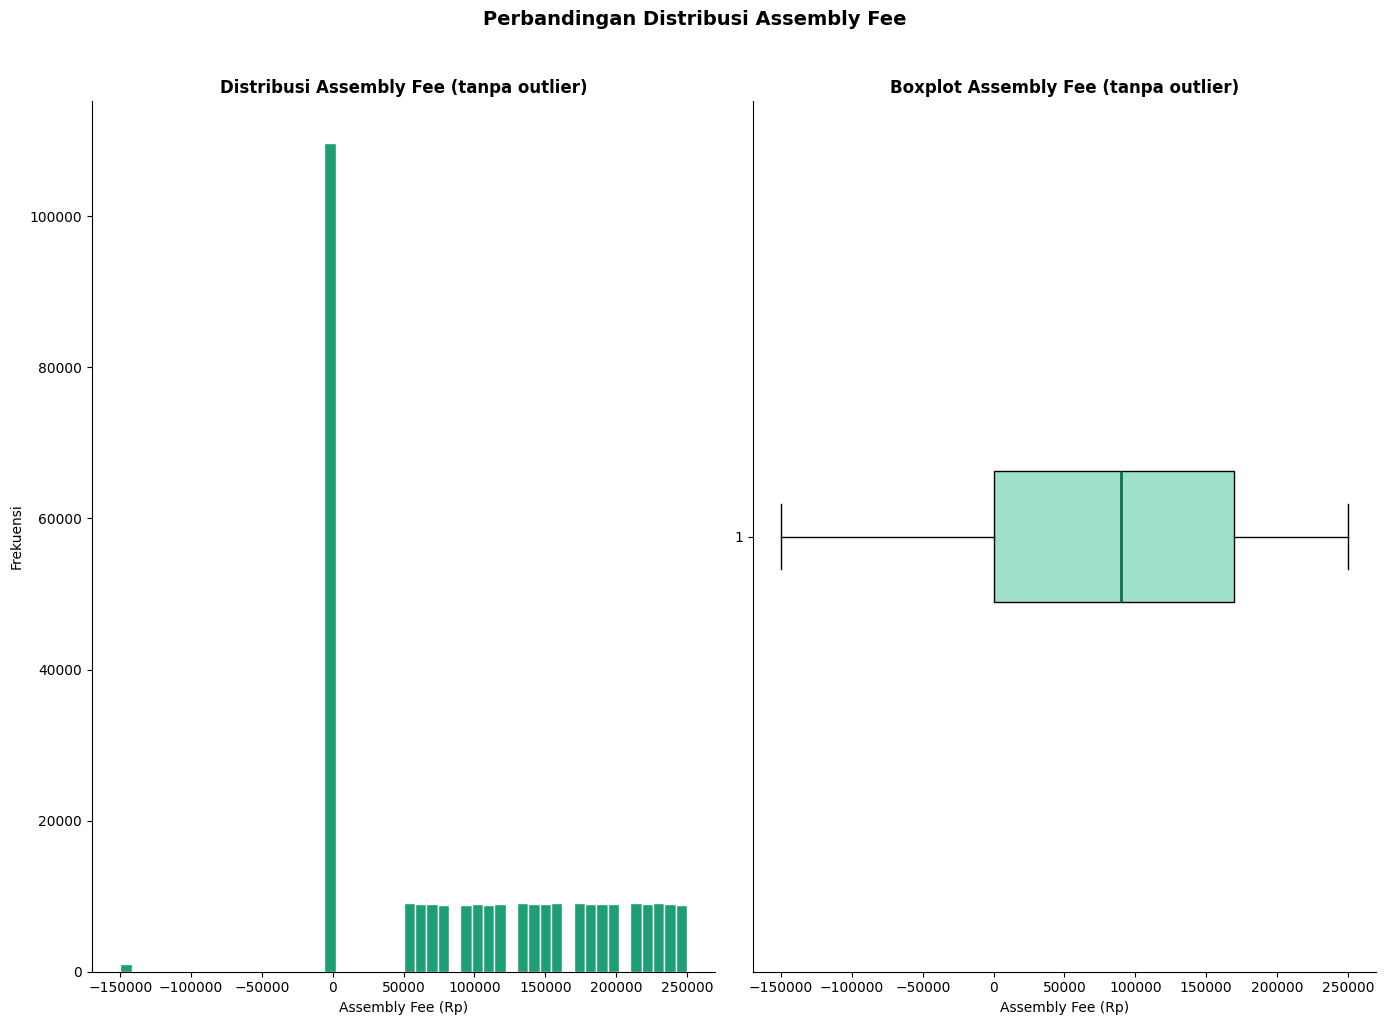

=== Dengan Outlier ===
count       Rp 300,000
mean        Rp 404,446
std       Rp 5,557,956
min        Rp -150,000
25%               Rp 0
50%          Rp 90,000
75%         Rp 170,000
max      Rp 99,900,000
Name: assembly_fee, dtype: object

=== Tanpa Outlier ===
count     Rp 299,067
mean       Rp 94,049
std        Rp 87,865
min      Rp -150,000
25%             Rp 0
50%        Rp 90,000
75%       Rp 170,000
max       Rp 250,000
Name: assembly_fee, dtype: object


In [ ]:
# Data tanpa outlier
fee_clean = order[order['assembly_fee'] != 99900000]['assembly_fee']
fee_outlier_val = order[order['assembly_fee'] == 99900000]['assembly_fee']

fig, axes = plt.subplots(1, 2, figsize=(14, 10))

# Chart 3: Histogram TANPA outlier
axes[0].hist(fee_clean, bins=50, color='#1D9E75', edgecolor='white')
axes[0].set_title('Distribusi Assembly Fee (tanpa outlier)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Assembly Fee (Rp)')
axes[0].set_ylabel('Frekuensi')
axes[0].spines[['top', 'right']].set_visible(False)

# Chart 4: Boxplot TANPA outlier
axes[1].boxplot(fee_clean, vert=False, patch_artist=True,
                   boxprops=dict(facecolor='#9FE1CB'),
                   medianprops=dict(color='#0F6E56', linewidth=2))
axes[1].set_title('Boxplot Assembly Fee (tanpa outlier)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Assembly Fee (Rp)')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Perbandingan Distribusi Assembly Fee',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Statistik perbandingan
print("=== Dengan Outlier ===")
print(order['assembly_fee'].describe().apply(lambda x: f"Rp {x:,.0f}"))
print("\n=== Tanpa Outlier ===")
print(fee_clean.describe().apply(lambda x: f"Rp {x:,.0f}"))

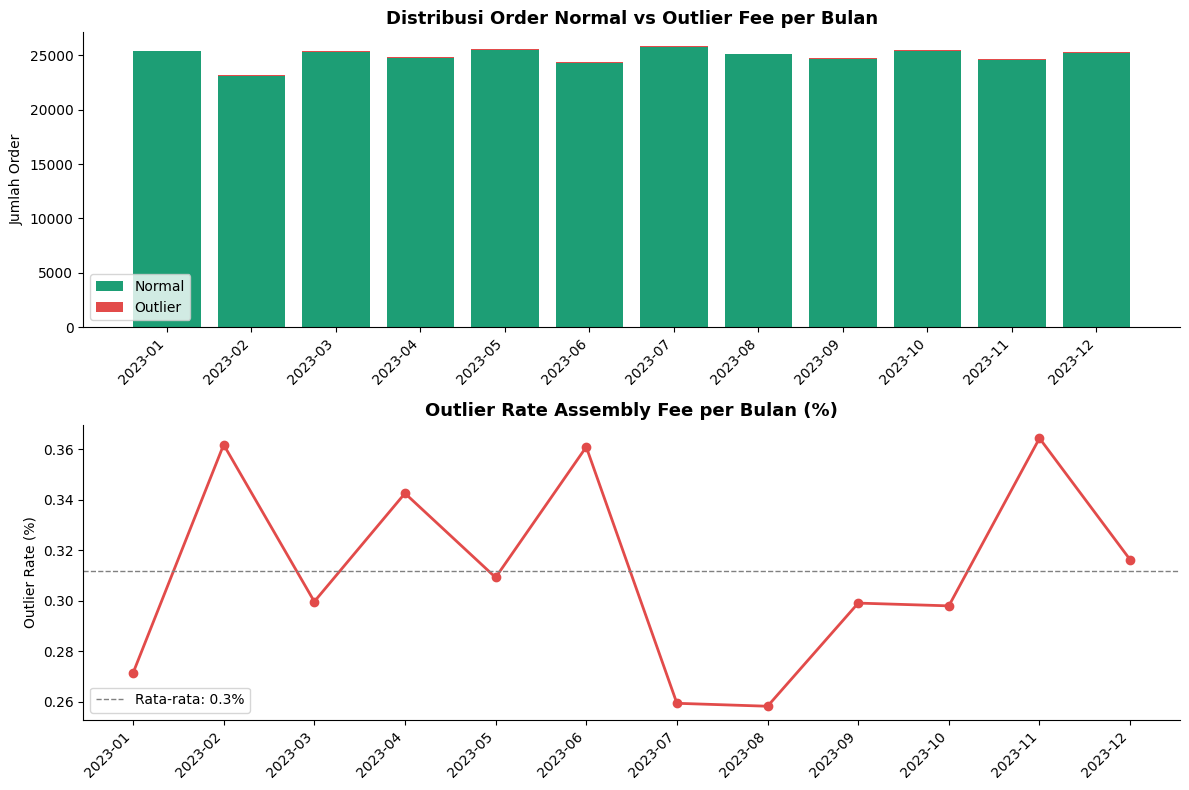

In [ ]:
# Pisahkan outlier dan normal
fee_outlier = order[order['assembly_fee'] == 99900000].copy()
fee_normal = order[order['assembly_fee'] != 99900000].copy()

# Tambah kolom bulan
fee_outlier['month'] = fee_outlier['order_date'].dt.to_period('M')
fee_normal['month'] = fee_normal['order_date'].dt.to_period('M')

# Hitung per bulan
outlier_by_month = fee_outlier.groupby('month').size().reset_index(name='outlier_count')
normal_by_month = fee_normal.groupby('month').size().reset_index(name='normal_count')

monthly_fee = outlier_by_month.merge(normal_by_month, on='month', how='outer').fillna(0)
monthly_fee['outlier_rate'] = monthly_fee['outlier_count'] / (monthly_fee['outlier_count'] + monthly_fee['normal_count']) * 100
monthly_fee['month'] = monthly_fee['month'].astype(str)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Chart 1: stacked bar count
axes[0].bar(monthly_fee['month'], monthly_fee['normal_count'], label='Normal', color='#1D9E75')
axes[0].bar(monthly_fee['month'], monthly_fee['outlier_count'],
            bottom=monthly_fee['normal_count'], label='Outlier', color='#E24B4A')
axes[0].set_title('Distribusi Order Normal vs Outlier Fee per Bulan', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Order')
axes[0].set_xticklabels(monthly_fee['month'], rotation=45, ha='right')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

# Chart 2: outlier rate per bulan
axes[1].plot(monthly_fee['month'], monthly_fee['outlier_rate'],
             marker='o', color='#E24B4A', linewidth=2)
axes[1].axhline(y=monthly_fee['outlier_rate'].mean(), color='gray',
                linestyle='--', linewidth=1,
                label=f"Rata-rata: {monthly_fee['outlier_rate'].mean():.1f}%")
axes[1].set_title('Outlier Rate Assembly Fee per Bulan (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Outlier Rate (%)')
axes[1].set_xticklabels(monthly_fee['month'], rotation=45, ha='right')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Hitung outlier rate per store
store_summary = order.groupby('store_id').agg(
    total=('order_id', 'count'),
    outlier=('assembly_fee', lambda x: (x == 99900000).sum())
).reset_index()

store_summary['outlier_rate'] = store_summary['outlier'] / store_summary['total'] * 100
store_summary = store_summary.sort_values('outlier_rate', ascending=False)

print(store_summary[store_summary['outlier'] > 0].to_string(index=False))
print(f"\nStore dengan outlier  : {(store_summary['outlier'] > 0).sum()}")
print(f"Store tanpa outlier   : {(store_summary['outlier'] == 0).sum()}")
print(f"Total store           : {len(store_summary)}")

store_id  total  outlier  outlier_rate
 DKR-030   7402       34      0.459335
 DKR-008   7629       31      0.406344
 DKR-012   7462       30      0.402037
 DKR-040   7541       30      0.397825
 DKR-011   7413       28      0.377715
 DKR-010   7469       28      0.374883
 DKR-021   7769       29      0.373278
 DKR-025   7502       28      0.373234
 DKR-015   7588       28      0.369004
 DKR-023   7553       27      0.357474
 DKR-004   7371       26      0.352734
 DKR-027   7406       26      0.351067
 DKR-036   7454       26      0.348806
 DKR-016   7463       26      0.348385
 DKR-032   7670       26      0.338983
 DKR-022   7592       25      0.329294
 DKR-002   7610       25      0.328515
 DKR-006   7524       24      0.318979
 DKR-026   7327       23      0.313907
 DKR-033   7338       23      0.313437
 DKR-035   7514       23      0.306095
 DKR-019   7598       23      0.302711
 DKR-013   7500       22      0.293333
 DKR-018   7675       22      0.286645
 DKR-001   7447       21 

Seluruh outlier pada kolom `assembly_fee` memiliki nilai identik Rp 99.900.000 yang tersebar merata di semua store. **Keseragaman nilai ini tidak konsisten dengan pola human error** yang umumnya menghasilkan variasi angka. Hipotesis yang lebih kuat: nilai ini merupakan ceiling value dari validasi field di sistem — kondisi tertentu seperti network timeout atau input lag menyebabkan sistem men-submit nilai maksimum yang diizinkan.

>**Rekomendasi: audit database schema untuk konfirmasi max_value pada field assembly_fee, dan tambahkan error handling yang menolak submission saat koneksi tidak stabil**

#### **Hasil Exploration Data Analysis**:

Preprocessing tabel `order` dilakukan untuk memastikan validitas data
sebelum digunakan dalam analisis. Beberapa temuan ditemukan dan
ditangani sebagai berikut.

### 1. Konversi Tipe Data
Kolom `order_date`, `delivery_date`, dan `installation_date` tersimpan sebagai `object` dan dikonversi ke tipe `datetime` agar operasi kalkulasi waktu dapat dilakukan.

###2. Logical Error — Installation Date Mendahului Delivery Date
Ditemukan **4.570 baris** (±1,5% dari total data) di mana `installation_date` tercatat lebih awal dari `delivery_date` — secara logis mustahil karena barang belum sampai namun sudah dirakit.

Investigasi lanjutan menunjukkan:
- **100% anomali adalah kasus off-by-one-month** — tanggal instalasi
  maju tepat satu bulan dari seharusnya atau tanggal barang sampai mundur 1 bulan
- Anomali tersebar merata di seluruh store dan installer tanpa
  konsentrasi di titik tertentu
- Error rate konsisten ±1,5% per bulan sepanjang tahun,
  dengan spike kecil di bulan Agustus dan November

**Simpulan:** Pola ini tidak konsisten dengan human error yang umumnya
acak dan bervariasi. Temuan mengarah pada **systematic bug di level
aplikasi** — kemungkinan kesalahan parsing format tanggal yang
menyebabkan bulan selalu ter-input satu nilai lebih awal. Data anomali
tidak dihapus, melainkan dipisahkan ke `df_anomaly` untuk keperluan
pelaporan data quality.

###3. Outlier Assembly Fee
Ditemukan **933 baris** (±0,3% dari total data) dengan nilai `assembly_fee` identik sebesar **Rp 99.900.000** yang tersebar merata di seluruh kategori produk dan semua store.

Investigasi lanjutan menunjukkan:
- Nilai outlier tunggal dan seragam — tidak bervariasi seperti
  lazimnya human error
- Tersebar di semua store tanpa konsentrasi lokasi tertentu
- Distribusi per bulan flat dan konsisten sepanjang tahun

**Simpulan:** Keseragaman nilai dan distribusinya mengindikasikan
**ceiling value bug di sistem input** — kondisi tertentu seperti network timeout atau input lag menyebabkan sistem men-submit nilai maksimum yang diizinkan field, bukan nilai aktual. Data outlier dipisahkan ke `df_anomaly` dan tidak diikutkan dalam analisis operasional.

###4. Missing Value & Filter Data
Missing value pada kolom `installer_id` dan `installation_date` disebabkan oleh order tanpa jasa instalasi (`No Assembly Required` dan `No Assembly Service`). Data ini dikeluarkan dari dataset utama karena tidak relevan dengan business context analisis.


### Referential Integrity

Memastikan bahwa `foreign key` dari setiap tabel valid.



In [ ]:
missing_skus = order[~order['sku_id'].isin(product['sku_id'])]
missing_stores = order[~order['store_id'].isin(store['store_id'])]

if missing_skus.empty:
    print('All sku_id in order_df have a match in the product table.')
else:
    print(f'There are {len(missing_skus)} rows in order_df with sku_id not found in the product table.')

if missing_stores.empty:
    print('All store_id in order_df have a match in the store table.')
else:
    print(f'There are {len(missing_stores)} rows in order_df with store_id not found in the store table.')

All sku_id in order_df have a match in the product table.
All store_id in order_df have a match in the store table.


### Merge Dataset

Menyatukan semua table menjadi satu dataset yang siap dianalisis lebih lanjut.

In [ ]:
# Dataframe utama — bersih, untuk analisis operasional
order_clean = order[
    (~order['order_id'].isin(is_anomaly['order_id'])) &
    (order['assembly_fee'] != 99900000) &
    (order['installation_status'] != 'No Assembly Service') &
    (order['installation_status'] != 'No Assembly Required')
].copy()

# Dataframe anomali — untuk reporting data quality
order_anomaly = order[
    (order['order_id'].isin(is_anomaly['order_id'])) |
    (order['assembly_fee'] == 99900000)
].copy()

print(f"order_clean  : {len(order_clean):,} baris")
print(f"order_anomaly: {len(order_anomaly):,} baris")

order_clean  : 184,796 baris
order_anomaly: 5,479 baris


In [ ]:
# Cek breakdown per kriteria filter
total = len(order)
anomaly_date = order['order_id'].isin(is_anomaly['order_id']).sum()
outlier_fee = (order['assembly_fee'] == 99900000).sum()
no_service = (order['installation_status'] == 'No Assembly Service').sum()
no_required = (order['installation_status'] == 'No Assembly Required').sum()

# Cek overlap antar kriteria
overlap_anomaly_fee = (
    order['order_id'].isin(is_anomaly['order_id']) &
    (order['assembly_fee'] == 99900000)
).sum()

overlap_anomaly_nostatus = (
    order['order_id'].isin(is_anomaly['order_id']) &
    (order['installation_status'].isin(['No Assembly Service', 'No Assembly Required']))
).sum()

overlap_fee_nostatus = (
    (order['assembly_fee'] == 99900000) &
    (order['installation_status'].isin(['No Assembly Service', 'No Assembly Required']))
).sum()

print(f"Total order              : {total:,}")
print(f"--- Kriteria filter ---")
print(f"Logical error tanggal    : {anomaly_date:,}")
print(f"Outlier assembly_fee     : {outlier_fee:,}")
print(f"No Assembly Service      : {no_service:,}")
print(f"No Assembly Required     : {no_required:,}")
print(f"--- Overlap ---")
print(f"Anomaly & outlier fee    : {overlap_anomaly_fee:,}")
print(f"Anomaly & no status      : {overlap_anomaly_nostatus:,}")
print(f"Outlier fee & no status  : {overlap_fee_nostatus:,}")
print(f"--- Hasil ---")
print(f"order_clean              : {len(order_clean):,}")
print(f"order_anomaly            : {len(order_anomaly):,}")
print(f"Selisih dari 190.275     : {190275 - len(order_clean):,}")

Total order              : 300,000
--- Kriteria filter ---
Logical error tanggal    : 4,570
Outlier assembly_fee     : 933
No Assembly Service      : 33,695
No Assembly Required     : 76,030
--- Overlap ---
Anomaly & outlier fee    : 24
Anomaly & no status      : 0
Outlier fee & no status  : 0
--- Hasil ---
order_clean              : 184,796
order_anomaly            : 5,479
Selisih dari 190.275     : 5,479


In [ ]:
# Merge utama untuk analisis
df = order_clean.merge(product, on='sku_id', how='left')
df = df.merge(store, on='store_id', how='left')

# Merge anomali untuk section data quality
df_anomaly = order_anomaly.merge(product, on='sku_id', how='left')
df_anomaly = df_anomaly.merge(store, on='store_id', how='left')

>Dataset operasional final (`order_clean`) terdiri dari **184.796
baris** yang siap digabungkan dengan tabel `product` dan `store`.

### Ringkasan Penanganan Data


| Kriteria Ekslusi         | Jumlah  |
|--------------------------|---------|
| No Assembly Required     | 76,030  |
| No Assembly Service      | 33,695  |
| Logical error tanggal    |  4,570  |
| Outlier assembly_fee     |    933  |
| Overlap (date & fee)     |    -24  |
| **Total ekslusi**        | **115,204** |
| **order_clean (final)**  | **184,796** |

# Analisis

In [ ]:
df.head()

,order_id,store_id,sku_id,order_date,delivery_date,installer_id,installation_date,installation_status,assembly_fee,product_name,category,is_assembly_required,store_name,channel_type
0,ORD-DKR00000001,DKR-029,SKU-FURN-00208,2023-08-10 17:00:00,2023-08-14 17:00:00,TUKANG-0882,2023-08-18 17:00:00,Success,120000,Furnitur Kayu Olahan 335,Dining Table,True,DEC Kelapa Gading 29,Physical Store
1,ORD-DKR00000002,DKR-012,SKU-FURN-01157,2023-01-30 10:00:00,2023-02-02 10:00:00,TUKANG-0560,2023-02-02 10:00:00,Success,110000,Furnitur Kayu Olahan 573,Wardrobe,True,DEC Bintaro 12,Physical Store
2,ORD-DKR00000003,DKR-032,SKU-FURN-00904,2023-07-13 20:00:00,2023-07-19 20:00:00,TUKANG-0631,2023-07-24 20:00:00,Success,230000,Furnitur Kayu Olahan 230,Wardrobe,True,DEC Medan 32,Physical Store
3,ORD-DKR00000004,DKR-005,SKU-FURN-00341,2023-09-27 19:00:00,2023-10-02 19:00:00,TUKANG-0484,2023-10-04 19:00:00,Success,100000,Furnitur Kayu Olahan 362,Wardrobe,True,DEC Medan 5,Physical Store
4,ORD-DKR00000006,DKR-005,SKU-FURN-00643,2023-10-29 15:00:00,2023-10-31 15:00:00,TUKANG-0787,2023-11-02 15:00:00,Success,180000,Furnitur Kayu Olahan 382,Office Chair,True,DEC Medan 5,Physical Store


## **GAP Delivery VS Installation**

In [ ]:
# Buat kolom delivery gap (dalam hari)
df['delivery_gap'] = (df['installation_date'] - df['delivery_date']).dt.days

# Statistik deskriptif
print("=== Statistik Delivery Gap (hari) ===")
print(df['delivery_gap'].describe().round(2))
print(f"\nMedian gap : {df['delivery_gap'].median():.1f} hari")
print(f"Gap = 0    : {(df['delivery_gap'] == 0).sum():,} baris ({(df['delivery_gap'] == 0).mean()*100:.1f}%)")
print(f"Gap <= 1   : {(df['delivery_gap'] <= 1).sum():,} baris ({(df['delivery_gap'] <= 1).mean()*100:.1f}%)")
print(f"Gap > 3    : {(df['delivery_gap'] > 3).sum():,} baris ({(df['delivery_gap'] > 3).mean()*100:.1f}%)")
print(f"Gap > 7    : {(df['delivery_gap'] > 7).sum():,} baris ({(df['delivery_gap'] > 7).mean()*100:.1f}%)")

=== Statistik Delivery Gap (hari) ===
count    184796.00
mean          2.51
std           1.71
min           0.00
25%           1.00
50%           3.00
75%           4.00
max           5.00
Name: delivery_gap, dtype: float64

Median gap : 3.0 hari
Gap = 0    : 30,764 baris (16.6%)
Gap <= 1   : 61,355 baris (33.2%)
Gap > 3    : 62,033 baris (33.6%)
Gap > 7    : 0 baris (0.0%)


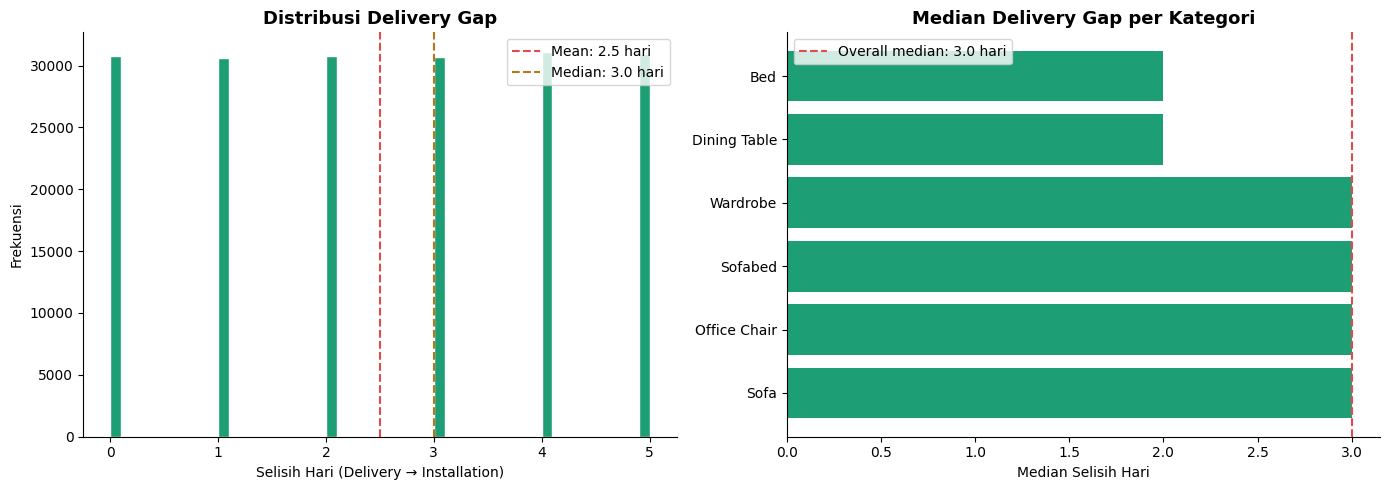

In [ ]:
# Visualisasi distribusi delivery gap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['delivery_gap'], bins=50, color='#1D9E75', edgecolor='white')
axes[0].axvline(df['delivery_gap'].mean(), color='#E24B4A', linestyle='--',
                linewidth=1.5, label=f"Mean: {df['delivery_gap'].mean():.1f} hari")
axes[0].axvline(df['delivery_gap'].median(), color='#BA7517', linestyle='--',
                linewidth=1.5, label=f"Median: {df['delivery_gap'].median():.1f} hari")
axes[0].set_title('Distribusi Delivery Gap', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Selisih Hari (Delivery → Installation)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

# Boxplot per kategori produk
gap_by_cat = df.groupby('category')['delivery_gap'].median().sort_values(ascending=False)
axes[1].barh(gap_by_cat.index, gap_by_cat.values, color='#1D9E75')
axes[1].axvline(df['delivery_gap'].median(), color='#E24B4A', linestyle='--',
                linewidth=1.5, label=f"Overall median: {df['delivery_gap'].median():.1f} hari")
axes[1].set_title('Median Delivery Gap per Kategori', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Median Selisih Hari')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Cek gap per channel — apakah App vs Physical Store berbeda?
print("=== Mean Delivery Gap per Channel ===")
print(df.groupby('channel_type')['delivery_gap'].agg(['mean', 'median', 'count']).round(2))

=== Mean Delivery Gap per Channel ===
                mean  median   count
channel_type                        
Mobile App      2.48     2.0    4603
Physical Store  2.51     3.0  175582
Web             2.52     3.0    4611


In [ ]:
# Cek gap per kategori lebih detail
print("=== Delivery Gap per Kategori ===")
print(df.groupby('category')['delivery_gap'].agg(
    mean='mean',
    median='median',
    pct_over_3=lambda x: (x > 3).mean() * 100
).round(2).sort_values('pct_over_3', ascending=False))

=== Delivery Gap per Kategori ===
              mean  median  pct_over_3
category                              
Sofa          2.51     3.0       33.83
Dining Table  2.50     2.0       33.62
Wardrobe      2.51     3.0       33.58
Bed           2.50     2.0       33.52
Office Chair  2.51     3.0       33.48
Sofabed       2.52     3.0       33.42


Delivery gap relatif seragam di semua kategori produk (mean 2-3 hari,
~33% over 3 hari). Tidak ditemukan korelasi antara kategori produk
dengan delivery gap.

Namun perlu dicatat keterbatasan data: tidak tersedia informasi tingkat
kompleksitas perakitan per produk. Idealnya bisa diukur dari perbandingan
antara `is_assembly_required` dengan keputusan customer menggunakan jasa
instalasi — namun data permintaan instalasi per order tidak tersedia di
dataset ini.

**Asumsi:** Tidak ada korelasi antara kategori produk dan delivery gap.

**Rekomendasi pengujian lanjutan:** Jika data kompleksitas tersedia,
gunakan Kruskal-Wallis Test untuk menguji apakah median delivery gap
berbeda secara signifikan antar kategori — karena distribusi gap
tidak normal (bounded 0-5 hari).

In [ ]:
# Cek apakah gap > 3 berkorelasi dengan failed installation
print("=== Installation Status per Gap Segment ===")
df['gap_segment'] = pd.cut(df['delivery_gap'],
                            bins=[-1, 0, 1, 3, 5],
                            labels=['Same day', '1 hari', '2-3 hari', '>3 hari'])

print(df.groupby(['gap_segment', 'installation_status']).size()
      .unstack(fill_value=0)
      .assign(pct_failed=lambda x:
              (x.get('Failed - Missing Parts', 0) + x.get('Failed - Damaged Panel', 0)) /
              x.sum(axis=1) * 100).round(2))

=== Installation Status per Gap Segment ===
installation_status  Failed - Damaged Panel  Failed - Missing Parts  Success  \
gap_segment                                                                    
Same day                               2475                    3756    24533   
1 hari                                 2562                    3689    24340   
2-3 hari                               5042                    7558    48808   
>3 hari                                5126                    7525    49382   

installation_status  pct_failed  
gap_segment                      
Same day                  20.25  
1 hari                    20.43  
2-3 hari                  20.52  
>3 hari                   20.39  


Untuk menguji apakah ada keterkaitan antara gap delivery dan installation maka diperlukan inferensi statistik. Karena variabelnya adalah `gap segment` (kategorik) vs `installation status` (kategorik), uji yang tepat adalah Chi-Square Test of Independence.

### Hipotesis:

* H0: Tidak ada hubungan antara delivery gap segment dan tingkat kegagalan instalasi
* H1: Ada hubungan antara delivery gap segment dan tingkat kegagalan instalasi

Jika p-value > 0.05, maka gagal tolak H0: artinya secara statistik terbukti tidak ada hubungan.

In [ ]:
from scipy.stats import chi2_contingency

# Buat contingency table
# Sederhanakan status menjadi binary: Success vs Failed
df['is_failed'] = df['installation_status'].isin([
    'Failed - Missing Parts',
    'Failed - Damaged Panel'
])

contingency = pd.crosstab(df['gap_segment'], df['is_failed'])
print("=== Contingency Table ===")
print(contingency)
print()

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"Chi-square statistic : {chi2:.4f}")
print(f"P-value              : {p_value:.4f}")
print(f"Degrees of freedom   : {dof}")
print(f"\nKesimpulan: {'Tolak H0 — ada hubungan signifikan' if p_value < 0.05 else 'Gagal tolak H0 — tidak ada hubungan signifikan'} (α = 0.05)")

=== Contingency Table ===
is_failed    False  True 
gap_segment              
Same day     24533   6231
1 hari       24340   6251
2-3 hari     48808  12600
>3 hari      49382  12651

Chi-square statistic : 0.9165
P-value              : 0.8214
Degrees of freedom   : 3

Kesimpulan: Gagal tolak H0 — tidak ada hubungan signifikan (α = 0.05)


### Uji Statistik: Delivery Gap vs Tingkat Kegagalan Instalasi

**Chi-Square Test of Independence**
- H0: Tidak ada hubungan antara delivery gap dan tingkat kegagalan instalasi
- H1: Ada hubungan antara delivery gap dan tingkat kegagalan instalasi

Hasil: p-value > 0.05 → Gagal tolak H0

**Simpulan:** Secara statistik tidak terdapat hubungan yang signifikan
antara lamanya selisih waktu delivery dan installation dengan tingkat
kegagalan instalasi.

Temuan ini mengindikasikan bahwa kegagalan instalasi bukan disebabkan
oleh waktu tunggu yang terlalu lama, melainkan lebih mungkin berasal
dari **kualitas produk di sisi supplier** — komponen sudah hilang atau
rusak sebelum proses instalasi dimulai.

Implikasi bisnis: solusi untuk menurunkan failed installation tidak
cukup hanya dengan mempercepat jadwal installer, tetapi harus
disertai dengan **supplier quality control** yang lebih ketat.

## PROBLEM 2 - Failed Installation Analysis

In [ ]:
print("=== Failed Installation Rate per Kategori ===")
failed_by_cat = df.groupby('category').agg(
    total=('order_id', 'count'),
    failed=('is_failed', 'sum')
).assign(
    failed_rate=lambda x: (x['failed'] / x['total'] * 100).round(2)
).sort_values('failed_rate', ascending=False)

print(failed_by_cat)

=== Failed Installation Rate per Kategori ===
              total  failed  failed_rate
category                                
Sofabed        6515    1359        20.86
Sofa          15020    3097        20.62
Dining Table  38359    7889        20.57
Bed           13022    2667        20.48
Office Chair  54217   11033        20.35
Wardrobe      57663   11688        20.27


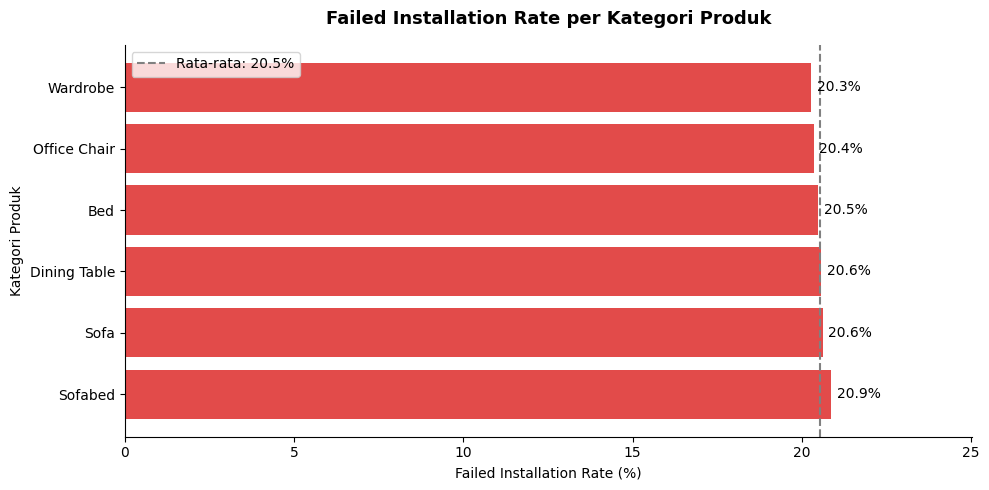

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    failed_by_cat.index,
    failed_by_cat['failed_rate'],
    color='#E24B4A'
)

# Annotasi angka
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=10)

# Garis rata-rata
avg = failed_by_cat['failed_rate'].mean()
ax.axvline(x=avg, color='gray', linestyle='--', linewidth=1.5,
           label=f'Rata-rata: {avg:.1f}%')

ax.set_title('Failed Installation Rate per Kategori Produk',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Failed Installation Rate (%)')
ax.set_ylabel('Kategori Produk')
ax.set_xlim(0, failed_by_cat['failed_rate'].max() * 1.2)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
print("=== Breakdown Jenis Kegagalan Instalasi ===")
status_counts = df['installation_status'].value_counts()
status_pct = df['installation_status'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    'jumlah': status_counts,
    'persentase': status_pct.round(2)
})
print(summary)

=== Breakdown Jenis Kegagalan Instalasi ===
                        jumlah  persentase
installation_status                       
Success                 147063       79.58
Failed - Missing Parts   22528       12.19
Failed - Damaged Panel   15205        8.23


In [ ]:
print("=== Jenis Kegagalan per Kategori Produk ===")
failed_type = df.groupby(['category', 'installation_status']).size().unstack(fill_value=0)
failed_type['total'] = failed_type.sum(axis=1)
failed_type['pct_missing_parts'] = (failed_type.get('Failed - Missing Parts', 0) / failed_type['total'] * 100).round(2)
failed_type['pct_damaged_panel'] = (failed_type.get('Failed - Damaged Panel', 0) / failed_type['total'] * 100).round(2)
print(failed_type.sort_values('pct_missing_parts', ascending=False))

=== Jenis Kegagalan per Kategori Produk ===
installation_status  Failed - Damaged Panel  Failed - Missing Parts  Success  \
category                                                                       
Bed                                    1044                    1623    10355   
Sofa                                   1232                    1865    11923   
Sofabed                                 553                     806     5156   
Dining Table                           3209                    4680    30470   
Office Chair                           4453                    6580    43184   
Wardrobe                               4714                    6974    45975   

installation_status  total  pct_missing_parts  pct_damaged_panel  
category                                                          
Bed                  13022              12.46               8.02  
Sofa                 15020              12.42               8.20  
Sofabed               6515              12.37  

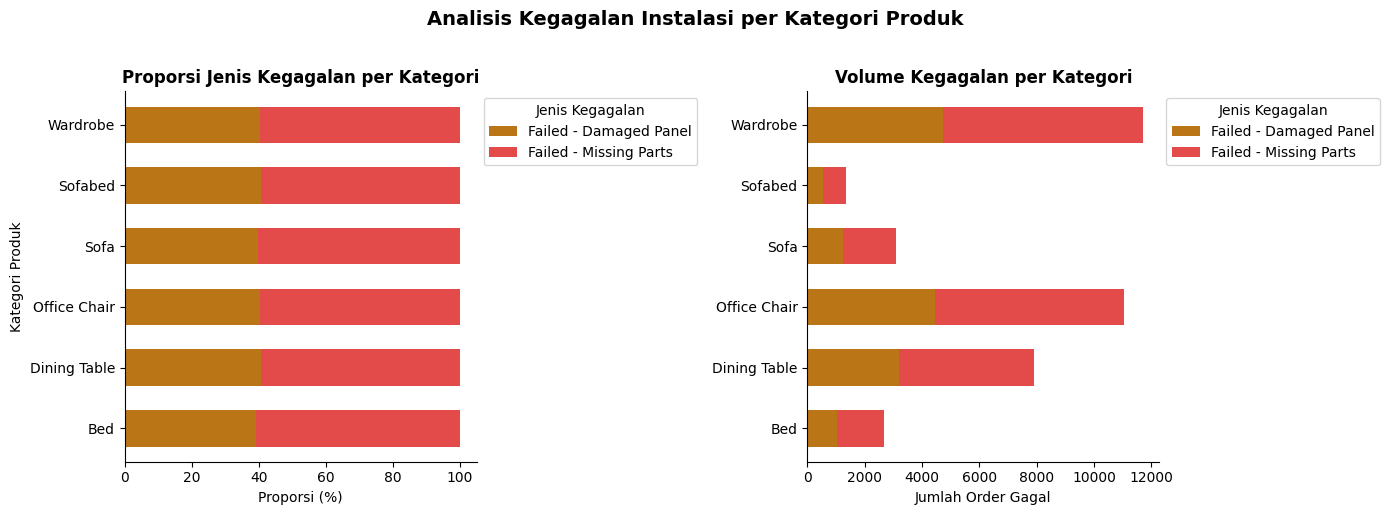

In [ ]:
# Siapkan data untuk plot
plot_data = df[df['is_failed']].groupby(
    ['category', 'installation_status']
).size().unstack(fill_value=0)

plot_data_pct = plot_data.div(plot_data.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: proporsi Missing Parts vs Damaged Panel per kategori
plot_data_pct.plot(
    kind='barh',
    stacked=True,
    color={
        'Failed - Missing Parts': '#E24B4A',
        'Failed - Damaged Panel': '#BA7517'
    },
    ax=axes[0],
    width=0.6
)
axes[0].set_title('Proporsi Jenis Kegagalan per Kategori',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Proporsi (%)')
axes[0].set_ylabel('Kategori Produk')
axes[0].legend(title='Jenis Kegagalan', bbox_to_anchor=(1, 1))
axes[0].spines[['top', 'right']].set_visible(False)

# Chart 2: total failed per kategori, breakdown by type
plot_data.plot(
    kind='barh',
    stacked=True,
    color={
        'Failed - Missing Parts': '#E24B4A',
        'Failed - Damaged Panel': '#BA7517'
    },
    ax=axes[1],
    width=0.6
)
axes[1].set_title('Volume Kegagalan per Kategori',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jumlah Order Gagal')
axes[1].set_ylabel('')
axes[1].legend(title='Jenis Kegagalan', bbox_to_anchor=(1, 1))
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Analisis Kegagalan Instalasi per Kategori Produk',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Filter hanya failed - missing parts
missing_parts = df[df['installation_status'] == 'Failed - Missing Parts'].copy()

print("=== Missing Parts Rate per Store ===")
store_missing = df.groupby(['store_id', 'store_name']).agg(
    total=('order_id', 'count'),
    missing_parts=('installation_status',
                   lambda x: (x == 'Failed - Missing Parts').sum())
).reset_index()

store_missing['missing_rate'] = (
    store_missing['missing_parts'] / store_missing['total'] * 100
).round(2)

store_missing = store_missing.sort_values('missing_rate', ascending=False)
print(store_missing.to_string(index=False))

=== Missing Parts Rate per Store ===
store_id           store_name  total  missing_parts  missing_rate
 DKR-029 DEC Kelapa Gading 29   4564            599         13.12
 DKR-034       DEC Bintaro 34   4661            605         12.98
 DKR-035      DEC Surabaya 35   4597            590         12.83
 DKR-027   DEC Alam Sutera 27   4496            572         12.72
 DKR-010        DEC Kemang 10   4642            590         12.71
 DKR-003         DEC Kemang 3   4571            580         12.69
 DKR-030        DEC Kemang 30   4540            573         12.62
 DKR-004  DEC Kelapa Gading 4   4516            568         12.58
 DKR-033   DEC Alam Sutera 33   4491            563         12.54
 DKR-037 DEC Kelapa Gading 37   4717            591         12.53
 DKR-012       DEC Bintaro 12   4594            575         12.52
 DKR-032         DEC Medan 32   4697            583         12.41
 DKR-011 DEC Kelapa Gading 11   4570            567         12.41
 DKR-020      DEC Surabaya 20   4649   

In [ ]:
print("=== Top 20 SKU dengan Missing Parts Tertinggi ===")
sku_missing = df.groupby(['sku_id', 'product_name', 'category']).agg(
    total=('order_id', 'count'),
    missing_parts=('installation_status',
                   lambda x: (x == 'Failed - Missing Parts').sum())
).reset_index()

sku_missing['missing_rate'] = (
    sku_missing['missing_parts'] / sku_missing['total'] * 100
).round(2)

# Filter SKU yang punya minimal 10 order agar rate-nya representatif
sku_missing_filtered = sku_missing[sku_missing['total'] >= 10]
print(sku_missing_filtered.sort_values(
    'missing_rate', ascending=False).head(20).to_string(index=False))

=== Top 20 SKU dengan Missing Parts Tertinggi ===
        sku_id               product_name     category  total  missing_parts  missing_rate
SKU-FURN-01059   Furnitur Kayu Olahan 753 Office Chair    176             39         22.16
SKU-FURN-01354   Furnitur Kayu Olahan 847 Office Chair    149             32         21.48
SKU-FURN-01359   Furnitur Kayu Olahan 760     Wardrobe    178             36         20.22
SKU-FURN-01234 Sofa Japandi Minimalis 560         Sofa    143             28         19.58
SKU-FURN-01094   Furnitur Kayu Olahan 628     Wardrobe    170             33         19.41
SKU-FURN-01462   Furnitur Kayu Olahan 795 Dining Table    181             35         19.34
SKU-FURN-00963   Furnitur Kayu Olahan 178     Wardrobe    171             33         19.30
SKU-FURN-01331 Sofa Japandi Minimalis 959         Sofa    167             32         19.16
SKU-FURN-00180   Furnitur Kayu Olahan 535 Office Chair    152             29         19.08
SKU-FURN-00256   Furnitur Kayu Olahan 98

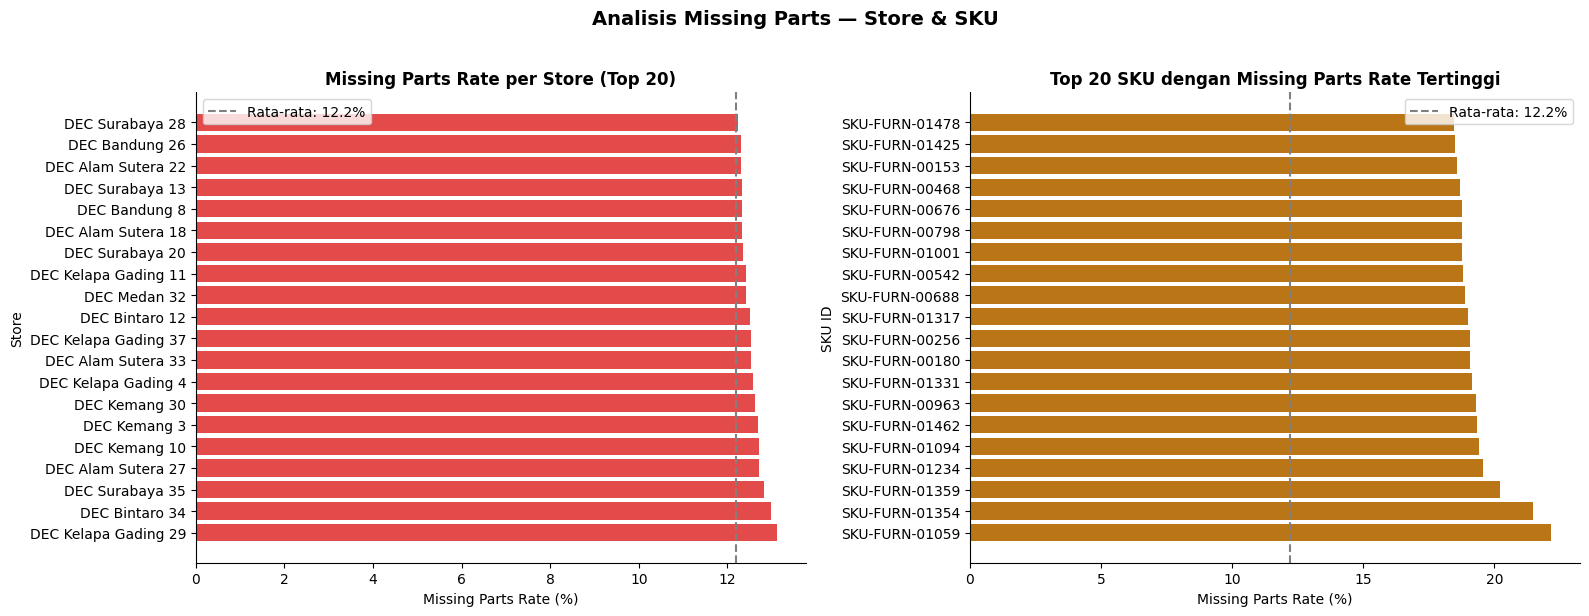

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Missing rate per store (top 20)
top_stores = store_missing.head(20)
axes[0].barh(top_stores['store_name'], top_stores['missing_rate'],
             color='#E24B4A')
axes[0].axvline(store_missing['missing_rate'].mean(),
                color='gray', linestyle='--', linewidth=1.5,
                label=f"Rata-rata: {store_missing['missing_rate'].mean():.1f}%")
axes[0].set_title('Missing Parts Rate per Store (Top 20)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Missing Parts Rate (%)')
axes[0].set_ylabel('Store')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

# Chart 2: Top 20 SKU bermasalah
top_skus = sku_missing_filtered.sort_values(
    'missing_rate', ascending=False).head(20)
axes[1].barh(top_skus['sku_id'], top_skus['missing_rate'],
             color='#BA7517')
axes[1].axvline(sku_missing_filtered['missing_rate'].mean(),
                color='gray', linestyle='--', linewidth=1.5,
                label=f"Rata-rata: {sku_missing_filtered['missing_rate'].mean():.1f}%")
axes[1].set_title('Top 20 SKU dengan Missing Parts Rate Tertinggi',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Missing Parts Rate (%)')
axes[1].set_ylabel('SKU ID')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Analisis Missing Parts — Store & SKU',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import chi2_contingency, chisquare
import numpy as np

# Test 1: Apakah proporsi missing parts konsisten per bulan?
df['month'] = df['order_date'].dt.to_period('M').astype(str)

monthly_status = df.groupby(['month', 'installation_status']).size().unstack(fill_value=0)
print("=== Distribusi Status per Bulan ===")
print(monthly_status)

# Chi-square test konsistensi per bulan
chi2, p_value, dof, expected = chi2_contingency(monthly_status)
print(f"\nChi-square : {chi2:.4f}")
print(f"P-value    : {p_value:.4f}")
print(f"Kesimpulan : {'Distribusi TIDAK konsisten per bulan' if p_value < 0.05 else 'Distribusi konsisten per bulan — ini baseline stabil'}")

=== Distribusi Status per Bulan ===
installation_status  Failed - Damaged Panel  Failed - Missing Parts  Success
month                                                                       
2023-01                                1255                    1855    12541
2023-02                                1174                    1736    11277
2023-03                                1287                    1859    12413
2023-04                                1282                    1921    12244
2023-05                                1284                    1877    12604
2023-06                                1174                    1882    11958
2023-07                                1290                    1961    12674
2023-08                                1319                    1873    12219
2023-09                                1266                    1873    12018
2023-10                                1327                    1892    12404
2023-11                                1

In [ ]:
# Test 2: Apakah proporsi missing parts konsisten per store?
store_status = df.groupby(['store_id', 'installation_status']).size().unstack(fill_value=0)

chi2_store, p_store, dof_store, _ = chi2_contingency(store_status)
print(f"\n=== Konsistensi per Store ===")
print(f"Chi-square : {chi2_store:.4f}")
print(f"P-value    : {p_store:.4f}")
print(f"Kesimpulan : {'Distribusi TIDAK konsisten per store' if p_store < 0.05 else 'Distribusi konsisten per store — tidak ada store yang outlier'}")


=== Konsistensi per Store ===
Chi-square : 74.9185
P-value    : 0.5779
Kesimpulan : Distribusi konsisten per store — tidak ada store yang outlier


In [ ]:
# Test 3: Apakah proporsi missing parts konsisten per kategori?
cat_status = df.groupby(['category', 'installation_status']).size().unstack(fill_value=0)

chi2_cat, p_cat, dof_cat, _ = chi2_contingency(cat_status)
print(f"\n=== Konsistensi per Kategori ===")
print(f"Chi-square : {chi2_cat:.4f}")
print(f"P-value    : {p_cat:.4f}")
print(f"Kesimpulan : {'Distribusi TIDAK konsisten per kategori' if p_cat < 0.05 else 'Distribusi konsisten per kategori — tidak ada kategori yang outlier'}")


=== Konsistensi per Kategori ===
Chi-square : 5.0574
P-value    : 0.8873
Kesimpulan : Distribusi konsisten per kategori — tidak ada kategori yang outlier


Error rate missing parts (12.2%) dan damaged panel (8%) terdistribusi
secara konsisten di semua dimensi — bulan, store, dan kategori produk.
Dengan confidence interval 95%, angka ini adalah baseline error yang
stabil dan inheren di sistem rantai pasok saat ini, bukan anomali
yang bisa diatasi dengan perbaikan operasional parsial.

>**Implikasi**: penurunan error rate secara signifikan hanya bisa dicapai
dengan intervensi di level upstream — standardisasi quality control
dari supplier, termasuk mandatory photo documentation realtime
sebelum produk meninggalkan gudang supplier.

In [ ]:
from scipy import stats

total = len(df)
missing = (df['installation_status'] == 'Failed - Missing Parts').sum()
damaged = (df['installation_status'] == 'Failed - Damaged Panel').sum()

# Confidence interval 95% untuk masing-masing
def proportion_ci(count, total, confidence=0.95):
    p = count / total
    se = np.sqrt(p * (1 - p) / total)
    z = stats.norm.ppf((1 + confidence) / 2)
    return p, p - z*se, p + z*se

p_missing, lower_m, upper_m = proportion_ci(missing, total)
p_damaged, lower_d, upper_d = proportion_ci(damaged, total)

print("=== Confidence Interval 95% Error Rate ===")
print(f"Missing Parts  : {p_missing*100:.2f}% (CI: {lower_m*100:.2f}% — {upper_m*100:.2f}%)")
print(f"Damaged Panel  : {p_damaged*100:.2f}% (CI: {lower_d*100:.2f}% — {upper_d*100:.2f}%)")
print(f"\nInterpretasi:")
print(f"Dengan 95% confidence, true missing parts rate ada di antara")
print(f"{lower_m*100:.2f}% dan {upper_m*100:.2f}%")
print(f"Angka ini adalah baseline error yang inheren di sistem saat ini.")

=== Confidence Interval 95% Error Rate ===
Missing Parts  : 12.19% (CI: 12.04% — 12.34%)
Damaged Panel  : 8.23% (CI: 8.10% — 8.35%)

Interpretasi:
Dengan 95% confidence, true missing parts rate ada di antara
12.04% dan 12.34%
Angka ini adalah baseline error yang inheren di sistem saat ini.


### Uji Statistik: Konsistensi Error Rate

Chi-Square Test of Independence dilakukan untuk menguji apakah
distribusi jenis kegagalan instalasi konsisten di semua dimensi.

| Dimensi    | Chi-square | P-value | Kesimpulan          |
|------------|------------|---------|---------------------|
| Per bulan  |18.0045     | 0.7057  | Distribusi konsisten |
| Per store  |74.9185     | 0.5779  | Distribusi konsisten |
| Per kategori|5.0574         | 0.8873  | Distribusi konsisten |

Seluruh p-value > 0.05 → Gagal tolak H0 di semua dimensi.

**Simpulan:** Missing parts rate (12.2%) dan damaged panel rate (8%)
adalah baseline error yang stabil dan inheren di sistem rantai pasok
Dekoruma saat ini. Tidak ada variabel operasional yang dapat
menjelaskan variasinya — artinya perbaikan parsial seperti
penggantian installer atau rotasi toko tidak akan mengubah angka ini.

**Implikasi bisnis:** Penurunan error rate secara signifikan hanya
bisa dicapai melalui intervensi di level upstream:

1. **Jangka pendek:** Pre-delivery inspection (PDI) di gudang —
   pemeriksaan kelengkapan komponen sebelum barang dikirim
2. **Jangka menengah:** Mandatory photo documentation realtime
   dari supplier sebelum produk meninggalkan gudang —
   diintegrasikan ke dalam validation app yang diusulkan
3. **Jangka panjang:** Supplier scorecard berbasis data —
   vendor dengan error rate di atas threshold dikenai penalti
   atau dikeluarkan dari daftar supplier

### Business Impact Analysis

In [ ]:
# =============================================
# ASSUMPTION TABLE — berbasis riset market
# =============================================

# Harga produk: pakai nilai tengah dari range
harga_estimasi = {
    'Sofa'         : 6_500_000,   # tengah 3-10jt
    'Sofabed'      : 7_000_000,   # tengah 4-10jt
    'Wardrobe'     : 3_500_000,   # tengah 2-5jt
    'Bed'          : 3_500_000,   # proxy dari Wardrobe
    'Office Chair' : 1_300_000,   # tengah 600rb-2jt
    'Dining Table' : 4_650_000,   # tengah 1.3-8jt
}

# Harga produk skenario LOW (batas bawah range)
harga_low = {
    'Sofa'         : 3_000_000,
    'Sofabed'      : 4_000_000,
    'Wardrobe'     : 2_000_000,
    'Bed'          : 2_000_000,
    'Office Chair' :   600_000,
    'Dining Table' : 1_300_000,
}

# Harga produk skenario HIGH (batas atas range)
harga_high = {
    'Sofa'         : 10_000_000,
    'Sofabed'      : 10_000_000,
    'Wardrobe'     :  5_000_000,
    'Bed'          :  5_000_000,
    'Office Chair' :  2_000_000,
    'Dining Table' :  8_000_000,
}

# Biaya operasional per failed installation
biaya_kirim      = 750_000   # tengah 500rb-1jt
biaya_retur      = biaya_kirim * 0.50   # 50% dari biaya kirim = 375rb
biaya_installer  = 150_000   # upah installer per kunjungan gagal
total_biaya_ops  = biaya_kirim + biaya_retur + biaya_installer

# Loss rate dari nilai produk
pct_loss_missing = 0.05   # 5% — produk dikembalikan, ada depresiasi/kerusakan minor
pct_loss_damaged = 0.15   # 15% — produk rusak, kerugian lebih besar

print("=== Tabel Asumsi ===")
print(f"{'Kategori':<15} {'Harga Low':>15} {'Harga Mid':>15} {'Harga High':>15}")
print("-" * 62)
for cat in harga_estimasi:
    print(f"{cat:<15} Rp {harga_low[cat]:>10,.0f} Rp {harga_estimasi[cat]:>10,.0f} Rp {harga_high[cat]:>10,.0f}")

print(f"\nBiaya kirim       : Rp {biaya_kirim:,.0f}")
print(f"Biaya retur (50%) : Rp {biaya_retur:,.0f}")
print(f"Biaya installer   : Rp {biaya_installer:,.0f}")
print(f"Total biaya ops   : Rp {total_biaya_ops:,.0f}")

=== Tabel Asumsi ===
Kategori              Harga Low       Harga Mid      Harga High
--------------------------------------------------------------
Sofa            Rp  3,000,000 Rp  6,500,000 Rp 10,000,000
Sofabed         Rp  4,000,000 Rp  7,000,000 Rp 10,000,000
Wardrobe        Rp  2,000,000 Rp  3,500,000 Rp  5,000,000
Bed             Rp  2,000,000 Rp  3,500,000 Rp  5,000,000
Office Chair    Rp    600,000 Rp  1,300,000 Rp  2,000,000
Dining Table    Rp  1,300,000 Rp  4,650,000 Rp  8,000,000

Biaya kirim       : Rp 750,000
Biaya retur (50%) : Rp 375,000
Biaya installer   : Rp 150,000
Total biaya ops   : Rp 1,275,000


In [ ]:
# =============================================
# FUNGSI KALKULASI IMPACT
# =============================================

def calc_impact(harga_dict, label):
    temp = df[df['is_failed']].groupby(
        ['category', 'installation_status']
    ).size().reset_index(name='count')

    temp['harga_produk'] = temp['category'].map(harga_dict)
    temp['biaya_ops'] = total_biaya_ops
    temp['biaya_loss'] = temp.apply(
        lambda row: row['harga_produk'] * pct_loss_missing
        if row['installation_status'] == 'Failed - Missing Parts'
        else row['harga_produk'] * pct_loss_damaged, axis=1
    )
    temp['total_biaya'] = (temp['biaya_ops'] + temp['biaya_loss']) * temp['count']

    total = temp['total_biaya'].sum()
    return total

# Hitung untuk tiga skenario harga
impact_low  = calc_impact(harga_low, 'Low')
impact_mid  = calc_impact(harga_estimasi, 'Mid')
impact_high = calc_impact(harga_high, 'High')

print("=== Estimasi Total Business Impact per Tahun ===")
print(f"Skenario Low  : Rp {impact_low:>15,.0f}")
print(f"Skenario Mid  : Rp {impact_mid:>15,.0f}")
print(f"Skenario High : Rp {impact_high:>15,.0f}")

=== Estimasi Total Business Impact per Tahun ===
Skenario Low  : Rp  53,551,950,000
Skenario Mid  : Rp  59,929,487,500
Skenario High : Rp  66,307,025,000


In [ ]:
# =============================================
# PROYEKSI PENGHEMATAN
# =============================================

scenarios = {
    'Konservatif (-30%)' : 0.30,
    'Moderat (-50%)'     : 0.50,
    'Agresif (-70%)'     : 0.70,
}

print("=== Proyeksi Penghematan Tahunan (Skenario Harga Mid) ===")
print(f"\n{'Skenario Penurunan':<25} {'Penghematan':>18} {'Sisa Kerugian':>18}")
print("-" * 63)
for label, pct in scenarios.items():
    saving    = impact_mid * pct
    remaining = impact_mid * (1 - pct)
    print(f"{label:<25} Rp {saving:>13,.0f}   Rp {remaining:>13,.0f}")

print(f"\n(Per bulan, skenario moderat: Rp {impact_mid * 0.50 / 12:,.0f})")

=== Proyeksi Penghematan Tahunan (Skenario Harga Mid) ===

Skenario Penurunan               Penghematan      Sisa Kerugian
---------------------------------------------------------------
Konservatif (-30%)        Rp 17,978,846,250   Rp 41,950,641,250
Moderat (-50%)            Rp 29,964,743,750   Rp 29,964,743,750
Agresif (-70%)            Rp 41,950,641,250   Rp 17,978,846,250

(Per bulan, skenario moderat: Rp 2,497,061,979)


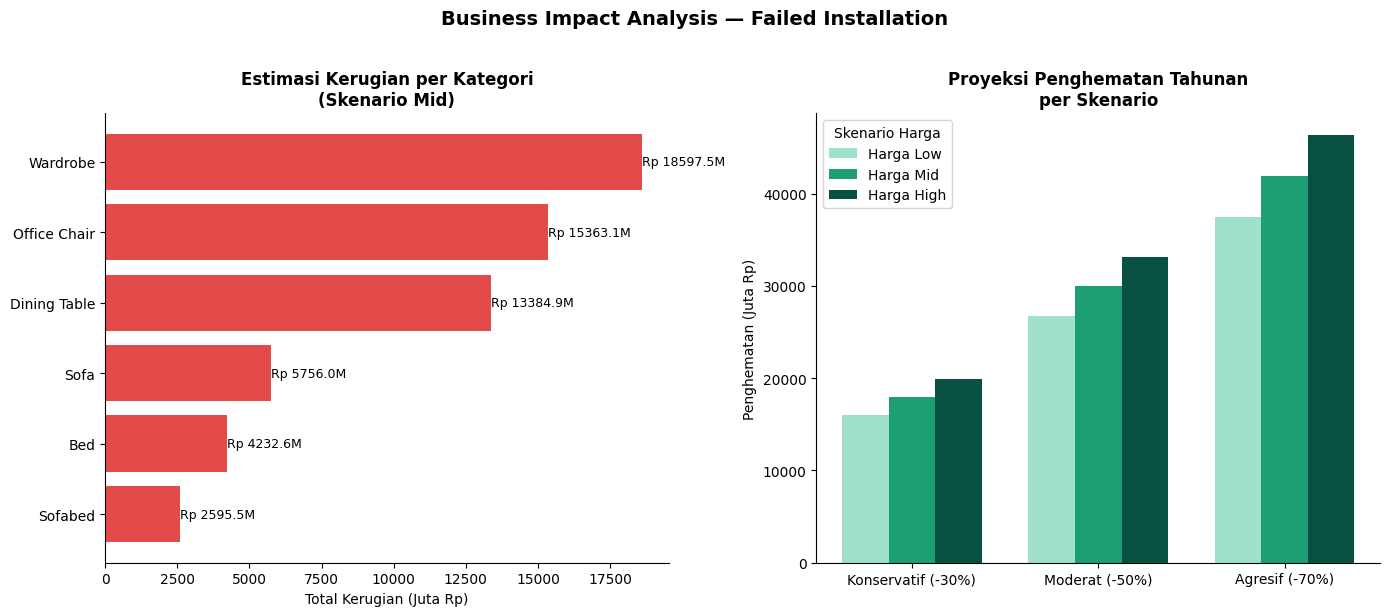

In [ ]:
# =============================================
# VISUALISASI
# =============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Impact per kategori (mid scenario)
cat_impact = df[df['is_failed']].groupby('category').apply(
    lambda x: (
        (x['installation_status'] == 'Failed - Missing Parts').sum() *
        (total_biaya_ops + harga_estimasi.get(x.name, 0) * pct_loss_missing) +
        (x['installation_status'] == 'Failed - Damaged Panel').sum() *
        (total_biaya_ops + harga_estimasi.get(x.name, 0) * pct_loss_damaged)
    )
).reset_index(name='impact')
cat_impact = cat_impact.sort_values('impact', ascending=True)

axes[0].barh(cat_impact['category'], cat_impact['impact'] / 1e6,
             color='#E24B4A')
axes[0].set_title('Estimasi Kerugian per Kategori\n(Skenario Mid)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Kerugian (Juta Rp)')
axes[0].spines[['top', 'right']].set_visible(False)
for i, (val, cat) in enumerate(zip(cat_impact['impact'], cat_impact['category'])):
    axes[0].text(val/1e6 + 0.5, i, f"Rp {val/1e6:.1f}M", va='center', fontsize=9)

# Chart 2: Proyeksi penghematan 3 skenario harga x 3 skenario penurunan
import numpy as np
x = np.arange(len(scenarios))
width = 0.25

savings = {
    'Low' : [impact_low * pct for pct in scenarios.values()],
    'Mid' : [impact_mid * pct for pct in scenarios.values()],
    'High': [impact_high * pct for pct in scenarios.values()],
}

colors = {'Low': '#9FE1CB', 'Mid': '#1D9E75', 'High': '#085041'}
for i, (label, vals) in enumerate(savings.items()):
    axes[1].bar(x + i * width, [v/1e6 for v in vals],
                width, label=f'Harga {label}', color=colors[label])

axes[1].set_title('Proyeksi Penghematan Tahunan\nper Skenario',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Penghematan (Juta Rp)')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(scenarios.keys())
axes[1].legend(title='Skenario Harga')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Business Impact Analysis — Failed Installation',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Business Impact Analysis — Failed Installation

#### Asumsi Kalkulasi

Estimasi kerugian dihitung berdasarkan tiga komponen biaya per
kejadian gagal instalasi:

| Komponen Biaya | Nilai |
|----------------|-------|
| Biaya pengiriman (estimasi tengah) | Rp 750.000 |
| Biaya retur (50% dari biaya kirim) | Rp 375.000 |
| Biaya installer sia-sia | Rp 150.000 |
| **Total biaya operasional per kejadian** | **Rp 1.275.000** |

Selain biaya operasional, setiap kegagalan juga menanggung kerugian
nilai produk:
- **Missing Parts:** 5% dari harga produk (depresiasi & kerusakan minor
  akibat proses retur)
- **Damaged Panel:** 15% dari harga produk (kerusakan struktural yang
  menurunkan nilai jual)

Harga produk diestimasikan berdasarkan riset pasar per kategori
(nilai tengah dari range harga yang tersedia di market):

| Kategori | Estimasi Harga |
|----------|---------------|
| Sofa | Rp 6.500.000 |
| Sofabed | Rp 7.000.000 |
| Wardrobe | Rp 3.500.000 |
| Bed | Rp 3.500.000 *(proxy Wardrobe)* |
| Office Chair | Rp 1.300.000 |
| Dining Table | Rp 4.650.000 |

> **Catatan:** Seluruh angka dalam analisis ini adalah estimasi
> berbasis asumsi pasar. Kalkulasi aktual membutuhkan data harga
> transaksi dan biaya logistik riil dari sistem Dekoruma.

---

#### Hasil Estimasi

Total estimasi kerugian tahunan akibat failed installation
(missing parts + damaged panel) pada skenario harga tengah:

**Rp 59.929.487.500 per tahun**

---

#### Proyeksi Penghematan jika Failed Rate Berhasil Diturunkan

| Skenario Penurunan | Penghematan/tahun | Sisa Kerugian |
|--------------------|-------------------|---------------|
| Konservatif (−30%) | Rp 17.978.846.250 | Rp 41.950.641.250 |
| Moderat (−50%) | Rp 29.964.743.750 | Rp 29.964.743.750 |
| Agresif (−70%) | Rp 41.950.641.250 | Rp 17.978.846.250 |

Pada skenario moderat, penghematan yang dapat direalisasikan setara
dengan **Rp 2,5 miliar per bulan.**

---

#### Interpretasi

Angka ini menggarisbawahi urgensi intervensi di level rantai pasok.
Dengan failed rate yang terbukti stabil secara statistik di semua
dimensi — waktu, toko, kategori, dan SKU — penurunan angka ini
tidak akan terjadi secara organik tanpa perubahan sistemik.

Tiga intervensi yang diproyeksikan dapat mendorong penurunan
failed rate secara signifikan:

1. **Pre-delivery inspection (PDI)** di gudang sebelum barang
   dikirim ke pelanggan — target: deteksi missing parts sebelum
   proses pengiriman dimulai
2. **Mandatory photo documentation** dari supplier sebagai bukti
   kelengkapan komponen sebelum produk meninggalkan gudang —
   diintegrasikan ke dalam validation app
3. **Supplier scorecard berbasis data** — vendor dengan failed rate
   di atas threshold dikenai penalti kontraktual atau dikeluarkan
   dari daftar mitra supplier
  

## PROBLEM 3

### Problem 3 — Showrooming Analysis

**Keterbatasan data:** Dataset tidak memuat informasi customer journey
atau domisili pelanggan. Analisis showrooming yang akurat membutuhkan
data kunjungan toko fisik yang dapat dikaitkan dengan transaksi digital
dari pelanggan yang sama.

**Rekomendasi pengumpulan data:**
- Implementasi customer ID yang konsisten lintas channel (App & DEC)
- Pencatatan store visit melalui loyalty program atau QR check-in di DEC
- Integrasi data CRM dengan transaction log

Tanpa data tersebut, analisis showrooming hanya dapat dilakukan
dengan proxy yang memiliki asumsi lemah dan berisiko misleading.

## Ringkasan Temuan & Rekomendasi

Seluruh analisis menunjukkan satu benang merah: **Dekoruma tidak
memiliki mekanisme validasi yang cukup**, baik di level sistem input
data maupun di level rantai pasok.

| Problem | Temuan Utama | Rekomendasi |
|---------|-------------|-------------|
| Data Quality | Systematic bug logical error (1.5%) & ceiling value bug assembly_fee (0.3%) | Validation layer di sistem input |
| Delivery Gap | 33.6% order menunggu >3 hari | Installer gig-model |
| Failed Installation | ~20% flat di semua dimensi, missing parts dominan | Supplier QC & PDI |
| Showrooming | Data tidak tersedia | Customer ID lintas channel |

Estimasi kerugian dari failed installation: **Rp 59,9 miliar/tahun**  
Potensi penghematan skenario moderat: **Rp 29,9 miliar/tahun**